## ****Air Quality Data Analysis****

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


df = pd.read_csv("air_quality.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Dark mode for Matplotlib
plt.style.use("dark_background")

# Dark mode for Seaborn
sns.set_theme(style="darkgrid", context="notebook")

# Dark mode for Plotly
PLOTLY_TEMPLATE = "plotly_dark"

pollutants = ["pm25", "pm10", "no2", "o3", "co"]
numeric_cols = pollutants + ["synthetic_aqi"]
colors = None  # Let libraries choose their default colors

In [3]:
df

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,Normal
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,Normal
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,Normal
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,Normal
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...
527127,2023-01-16 09:00:00,D17,8.880395,17.091528,14.511241,27.730812,1.017884,27.0,Good,0,Normal
527128,2023-09-03 16:00:00,D18,14.708616,26.131330,21.595183,55.328278,0.718461,55.0,Moderate,0,Normal
527129,2023-01-31 12:00:00,D10,29.451436,52.058873,33.247696,39.081503,0.621691,73.0,Moderate,0,Normal
527130,2023-08-22 17:00:00,D12,53.340108,85.719320,54.080943,43.769245,0.860015,133.0,Unhealthy for Sensitive Groups,0,Normal


#### ***PANDAS***

- **Display top 10 rows**

In [4]:
df.head(10)

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,Normal
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,Normal
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,Normal
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,Normal
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,Normal
5,2025-05-28 00:00:00,D20,10.788017,22.500426,15.822771,22.926125,0.776106,26.0,Good,0,Normal
6,2023-09-01 20:00:00,D10,19.496830,37.542131,23.851285,40.002182,0.773935,48.0,Good,0,Normal
7,2024-03-23 23:00:00,D06,10.852200,22.266415,15.478677,8.552250,0.498035,27.0,Good,0,Normal
8,2024-02-20 04:00:00,D14,13.758044,18.978176,16.987760,9.429161,0.522662,34.0,Good,0,Normal
9,2024-03-04 06:00:00,D08,33.876804,59.456649,32.797248,29.351694,1.222775,84.0,Moderate,0,Normal


- **Display Bottom 10 rows**

In [5]:
df.tail(10)

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status
527122,2023-12-27 10:00:00,D04,12.858813,22.126397,26.124620,39.369817,0.815740,39.0,Good,0,Normal
527123,2023-11-22 14:00:00,D19,9.318693,20.714151,21.044877,38.418147,0.689358,38.0,Good,0,Normal
527124,2024-08-21 18:00:00,D16,13.045152,19.731938,20.571130,34.433981,0.821000,34.0,Good,0,Normal
527125,2024-02-13 16:00:00,D16,18.425170,31.278214,24.501329,39.699184,1.181168,46.0,Good,0,Normal
527126,2024-06-21 06:00:00,D05,15.725037,32.233944,21.658923,43.725179,0.930986,43.0,Good,0,Normal
527127,2023-01-16 09:00:00,D17,8.880395,17.091528,14.511241,27.730812,1.017884,27.0,Good,0,Normal
527128,2023-09-03 16:00:00,D18,14.708616,26.131330,21.595183,55.328278,0.718461,55.0,Moderate,0,Normal
527129,2023-01-31 12:00:00,D10,29.451436,52.058873,33.247696,39.081503,0.621691,73.0,Moderate,0,Normal
527130,2023-08-22 17:00:00,D12,53.340108,85.719320,54.080943,43.769245,0.860015,133.0,Unhealthy for Sensitive Groups,0,Normal
527131,2024-11-23 16:00:00,D09,11.978192,21.918493,15.918153,29.578698,0.640476,29.0,Good,0,Normal


**Shape of the dataset**

In [6]:
df.shape

(527132, 11)

**Column Names**

In [7]:
df.columns

Index(['timestamp', 'district_id', 'pm25', 'pm10', 'no2', 'o3', 'co',
       'synthetic_aqi', 'air_quality_category', 'pollution_alert_flag',
       'sensor_status'],
      dtype='object')

In [8]:
df.columns.tolist()

['timestamp',
 'district_id',
 'pm25',
 'pm10',
 'no2',
 'o3',
 'co',
 'synthetic_aqi',
 'air_quality_category',
 'pollution_alert_flag',
 'sensor_status']

**Data Types**

In [9]:
df.dtypes

timestamp               datetime64[ns]
district_id                     object
pm25                           float64
pm10                           float64
no2                            float64
o3                             float64
co                             float64
synthetic_aqi                  float64
air_quality_category            object
pollution_alert_flag             int64
sensor_status                   object
dtype: object

- **Missing values**

In [10]:
df.isnull().sum()

timestamp                  0
district_id                0
pm25                    5441
pm10                    5441
no2                     5441
o3                      5441
co                      5441
synthetic_aqi           5441
air_quality_category       0
pollution_alert_flag       0
sensor_status              0
dtype: int64

- **Missing-value percentage**

In [11]:
(df.isnull().mean() * 100).round(2)

timestamp               0.00
district_id             0.00
pm25                    1.03
pm10                    1.03
no2                     1.03
o3                      1.03
co                      1.03
synthetic_aqi           1.03
air_quality_category    0.00
pollution_alert_flag    0.00
sensor_status           0.00
dtype: float64

- **Duplicate rows**

In [12]:
df.duplicated().sum()

np.int64(1052)

- **Statistical Summary**

In [13]:
df.describe()

,timestamp,pm25,pm10,no2,o3,co,synthetic_aqi,pollution_alert_flag
count,527132,521691.000000,521691.000000,521691.000000,521691.000000,521691.000000,521691.000000,527132.000000
mean,2024-07-01 23:40:23.183566592,17.259193,30.886496,22.789367,33.768696,0.833976,49.923156,0.015649
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.105382,2.000000,0.000000
25%,2023-10-02 00:00:00,9.320662,18.858760,14.708434,18.742482,0.593102,30.000000,0.000000
50%,2024-07-01 23:00:00,13.713142,25.803213,19.927996,32.207801,0.737591,43.000000,0.000000
75%,2025-04-01 23:00:00,20.823952,36.568153,27.842772,46.704131,0.973902,61.000000,0.000000
max,2025-12-31 23:00:00,119.192134,185.001350,169.678793,109.441409,6.984994,297.000000,1.000000
std,NaN,12.723393,19.318668,11.721318,19.540075,0.361331,30.220188,0.124113


- **Statistical summary including categorical columns**

In [14]:
df.describe(include="all")

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status
count,527132,527132,521691.000000,521691.000000,521691.000000,521691.000000,521691.000000,521691.000000,527132,527132.000000,527132
unique,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,3
top,NaN,D08,NaN,NaN,NaN,NaN,NaN,NaN,Good,NaN,Normal
freq,NaN,26373,NaN,NaN,NaN,NaN,NaN,NaN,323467,NaN,521691
mean,2024-07-01 23:40:23.183566592,NaN,17.259193,30.886496,22.789367,33.768696,0.833976,49.923156,NaN,0.015649,NaN
min,2023-01-01 00:00:00,NaN,0.000000,0.000000,0.000000,0.000000,0.105382,2.000000,NaN,0.000000,NaN
25%,2023-10-02 00:00:00,NaN,9.320662,18.858760,14.708434,18.742482,0.593102,30.000000,NaN,0.000000,NaN
50%,2024-07-01 23:00:00,NaN,13.713142,25.803213,19.927996,32.207801,0.737591,43.000000,NaN,0.000000,NaN
75%,2025-04-01 23:00:00,NaN,20.823952,36.568153,27.842772,46.704131,0.973902,61.000000,NaN,0.000000,NaN
max,2025-12-31 23:00:00,NaN,119.192134,185.001350,169.678793,109.441409,6.984994,297.000000,NaN,1.000000,NaN


- **Unique districts**

In [15]:
df["district_id"].unique()

array(['D11', 'D08', 'D02', 'D09', 'D14', 'D20', 'D10', 'D06', 'D04',
       'D17', 'D13', 'D03', 'D01', 'D16', 'D15', 'D19', 'D18', 'D07',
       'D12', 'D05'], dtype=object)

In [16]:
print(sorted(df["district_id"].unique()))

['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'D20']


- **Air-quality category counts**

In [17]:
df["air_quality_category"].value_counts()

air_quality_category
Good                              323467
Moderate                          174369
Unhealthy for Sensitive Groups     21047
Unhealthy                           5877
Very Unhealthy                      2372
Name: count, dtype: int64

In [18]:
print(df["air_quality_category"].value_counts())

air_quality_category
Good                              323467
Moderate                          174369
Unhealthy for Sensitive Groups     21047
Unhealthy                           5877
Very Unhealthy                      2372
Name: count, dtype: int64


- **Sensor-status counts**

In [19]:
df["sensor_status"].value_counts()


sensor_status
Normal                521691
Communication-Loss      5339
Outage-Affected          102
Name: count, dtype: int64

In [20]:
print(df["sensor_status"].value_counts())

sensor_status
Normal                521691
Communication-Loss      5339
Outage-Affected          102
Name: count, dtype: int64


- **Pollution-alert counts**

In [21]:
print(df["pollution_alert_flag"].value_counts())

pollution_alert_flag
0    518883
1      8249
Name: count, dtype: int64


- **Date range**

In [22]:
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Start: 2023-01-01 00:00:00
End: 2025-12-31 23:00:00


- **Create year column**

In [23]:
df["year"] = df["timestamp"].dt.year
print(df[["timestamp", "year"]].head())


            timestamp  year
0 2024-05-01 22:00:00  2024
1 2023-11-21 06:00:00  2023
2 2024-09-02 10:00:00  2024
3 2025-03-14 23:00:00  2025
4 2024-09-10 07:00:00  2024


In [24]:
df.head()

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status,year
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,Normal,2024
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,Normal,2023
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,Normal,2024
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,Normal,2025
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,Normal,2024


- **Create month column**

In [25]:
df["month"] = df["timestamp"].dt.month
print(df["month"].value_counts().sort_index())

month
1     44726
2     40892
3     44745
4     43275
5     44725
6     43284
7     44728
8     44726
9     43275
10    44727
11    43296
12    44733
Name: count, dtype: int64


In [26]:
df.head()

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status,year,month
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,Normal,2024,5
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,Normal,2023,11
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,Normal,2024,9
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,Normal,2025,3
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,Normal,2024,9


- **Create month name column**

In [27]:
df["month_name"] = df["timestamp"].dt.month_name()
print(df["month_name"].value_counts())

month_name
March        44745
December     44733
July         44728
October      44727
August       44726
January      44726
May          44725
November     43296
June         43284
September    43275
April        43275
February     40892
Name: count, dtype: int64


In [28]:
df.head()

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status,year,month,month_name
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,Normal,2024,5,May
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,Normal,2023,11,November
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,Normal,2024,9,September
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,Normal,2025,3,March
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,Normal,2024,9,September


- **Create hour column**

In [29]:
df["hour"] = df["timestamp"].dt.hour
print(df["hour"].value_counts().sort_index())

hour
0     21979
1     21970
2     21959
3     21960
4     21964
5     21964
6     21967
7     21963
8     21972
9     21962
10    21960
11    21971
12    21974
13    21958
14    21966
15    21956
16    21957
17    21964
18    21960
19    21959
20    21962
21    21961
22    21970
23    21954
Name: count, dtype: int64


In [30]:
df

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status,year,month,month_name,hour
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,Normal,2024,5,May,22
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,Normal,2023,11,November,6
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,Normal,2024,9,September,10
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,Normal,2025,3,March,23
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,Normal,2024,9,September,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527127,2023-01-16 09:00:00,D17,8.880395,17.091528,14.511241,27.730812,1.017884,27.0,Good,0,Normal,2023,1,January,9
527128,2023-09-03 16:00:00,D18,14.708616,26.131330,21.595183,55.328278,0.718461,55.0,Moderate,0,Normal,2023,9,September,16
527129,2023-01-31 12:00:00,D10,29.451436,52.058873,33.247696,39.081503,0.621691,73.0,Moderate,0,Normal,2023,1,January,12
527130,2023-08-22 17:00:00,D12,53.340108,85.719320,54.080943,43.769245,0.860015,133.0,Unhealthy for Sensitive Groups,0,Normal,2023,8,August,17


- **Create day-of-week column**

In [31]:
df["day_name"] = df["timestamp"].dt.day_name()
print(df["day_name"].value_counts())

day_name
Sunday       75525
Monday       75514
Tuesday      75508
Wednesday    75501
Friday       75030
Thursday     75030
Saturday     75024
Name: count, dtype: int64


In [32]:
df

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status,year,month,month_name,hour,day_name
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,Normal,2024,5,May,22,Wednesday
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,Normal,2023,11,November,6,Tuesday
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,Normal,2024,9,September,10,Monday
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,Normal,2025,3,March,23,Friday
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,Normal,2024,9,September,7,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527127,2023-01-16 09:00:00,D17,8.880395,17.091528,14.511241,27.730812,1.017884,27.0,Good,0,Normal,2023,1,January,9,Monday
527128,2023-09-03 16:00:00,D18,14.708616,26.131330,21.595183,55.328278,0.718461,55.0,Moderate,0,Normal,2023,9,September,16,Sunday
527129,2023-01-31 12:00:00,D10,29.451436,52.058873,33.247696,39.081503,0.621691,73.0,Moderate,0,Normal,2023,1,January,12,Tuesday
527130,2023-08-22 17:00:00,D12,53.340108,85.719320,54.080943,43.769245,0.860015,133.0,Unhealthy for Sensitive Groups,0,Normal,2023,8,August,17,Tuesday


- **Average AQI by district**

In [33]:
df.groupby("district_id")["synthetic_aqi"].mean().sort_values(ascending=False)

district_id
D03    127.457177
D12     83.349933
D10     64.761717
D01     54.879580
D08     54.630811
D02     49.279420
D11     48.969920
D17     47.012876
D15     44.761230
D06     43.841841
D05     42.172460
D18     42.111746
D14     41.105859
D04     38.892694
D07     38.621073
D20     37.733374
D16     37.445058
D09     36.706780
D19     33.168424
D13     31.605007
Name: synthetic_aqi, dtype: float64

- **Average pollutants by district**

In [34]:
df.groupby("district_id")[pollutants].mean().round(2)

,pm25,pm10,no2,o3,co
district_id,,,,,
D01,20.53,35.79,29.23,37.39,1.21
D02,17.41,31.13,26.33,37.22,1.15
D03,51.15,81.72,46.20,38.65,0.65
D04,12.23,23.34,19.46,31.97,0.88
D05,14.22,26.30,20.79,33.26,0.86
D06,15.29,27.91,20.92,33.52,0.80
D07,11.89,22.85,18.99,32.34,0.85
D08,20.77,36.15,26.36,35.68,0.92
D09,9.91,19.88,17.40,32.52,0.84


- **Average AQI by air-quality category**

In [35]:
df.groupby("air_quality_category")["synthetic_aqi"].mean().sort_values()

air_quality_category
Good                               32.751185
Moderate                           66.710366
Unhealthy for Sensitive Groups    120.269802
Unhealthy                         170.295646
Very Unhealthy                    236.586706
Name: synthetic_aqi, dtype: float64

- **Monthly AQI summary**

In [36]:
monthly_aqi = df.set_index("timestamp")["synthetic_aqi"].resample("ME").mean()
monthly_aqi

timestamp
2023-01-31    45.259237
2023-02-28    45.170627
2023-03-31    46.835445
2023-04-30    48.348932
2023-05-31    52.311551
2023-06-30    55.910688
2023-07-31    56.934251
2023-08-31    56.600041
2023-09-30    50.928416
2023-10-31    48.837761
2023-11-30    46.472704
2023-12-31    45.800095
2024-01-31    44.918283
2024-02-29    46.182075
2024-03-31    46.864514
2024-04-30    48.554675
2024-05-31    50.849742
2024-06-30    56.865242
2024-07-31    56.756136
2024-08-31    55.265415
2024-09-30    51.790146
2024-10-31    48.000948
2024-11-30    46.194466
2024-12-31    45.289807
2025-01-31    45.544007
2025-02-28    44.781177
2025-03-31    46.710699
2025-04-30    48.919448
2025-05-31    51.932223
2025-06-30    57.294262
2025-07-31    56.612925
2025-08-31    54.666079
2025-09-30    52.201608
2025-10-31    48.916780
2025-11-30    45.860447
2025-12-31    45.988821
Freq: ME, Name: synthetic_aqi, dtype: float64

#### ***MATPLOTLIB***

- **Histogram of PM2.5**

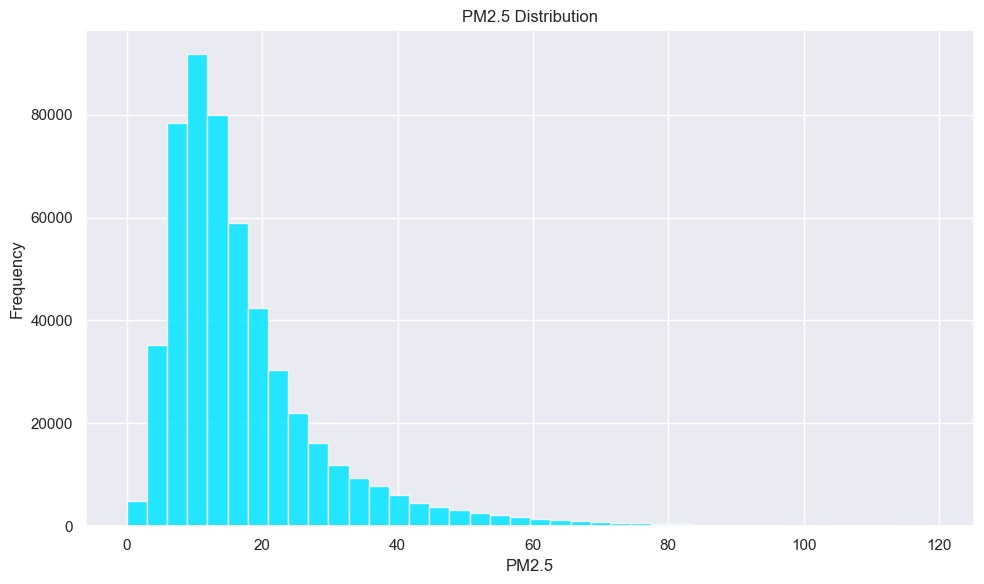

In [37]:
plt.figure(figsize=(10, 6))
plt.hist(df["pm25"].dropna(), bins=40, color="#00E5FF", edgecolor="white", alpha=0.85)
plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.tight_layout()

- **Histogram of AQI**

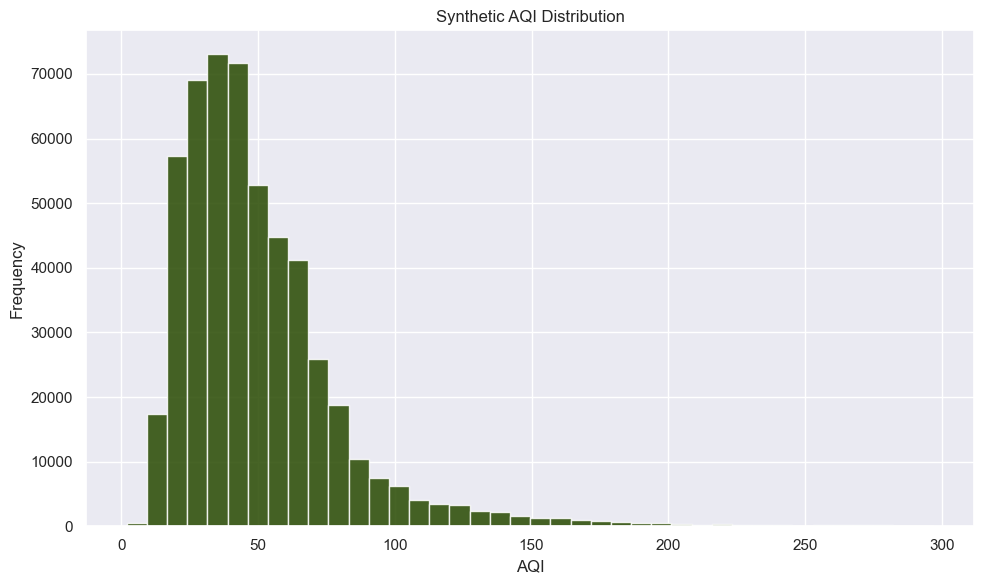

In [38]:
plt.figure(figsize=(10, 6))
plt.hist(df["synthetic_aqi"].dropna(), bins=40, color="#274900", edgecolor="white", alpha=0.85)
plt.title("Synthetic AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.tight_layout()

- **Line chart of daily AQI**

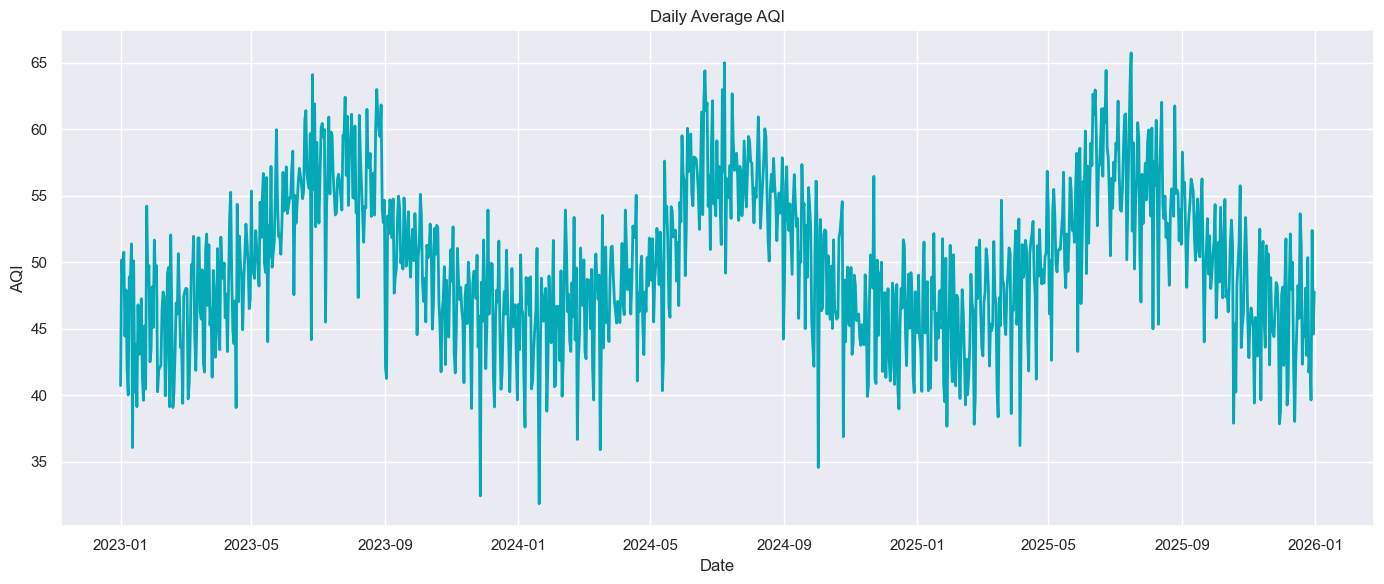

In [39]:
daily_aqi = df.set_index("timestamp")["synthetic_aqi"].resample("D").mean()
plt.figure(figsize=(14, 6))
plt.plot(daily_aqi.index, daily_aqi.values, color="#04A9B8", linewidth=2)
plt.title("Daily Average AQI")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.tight_layout()

- **Monthly AQI trend**

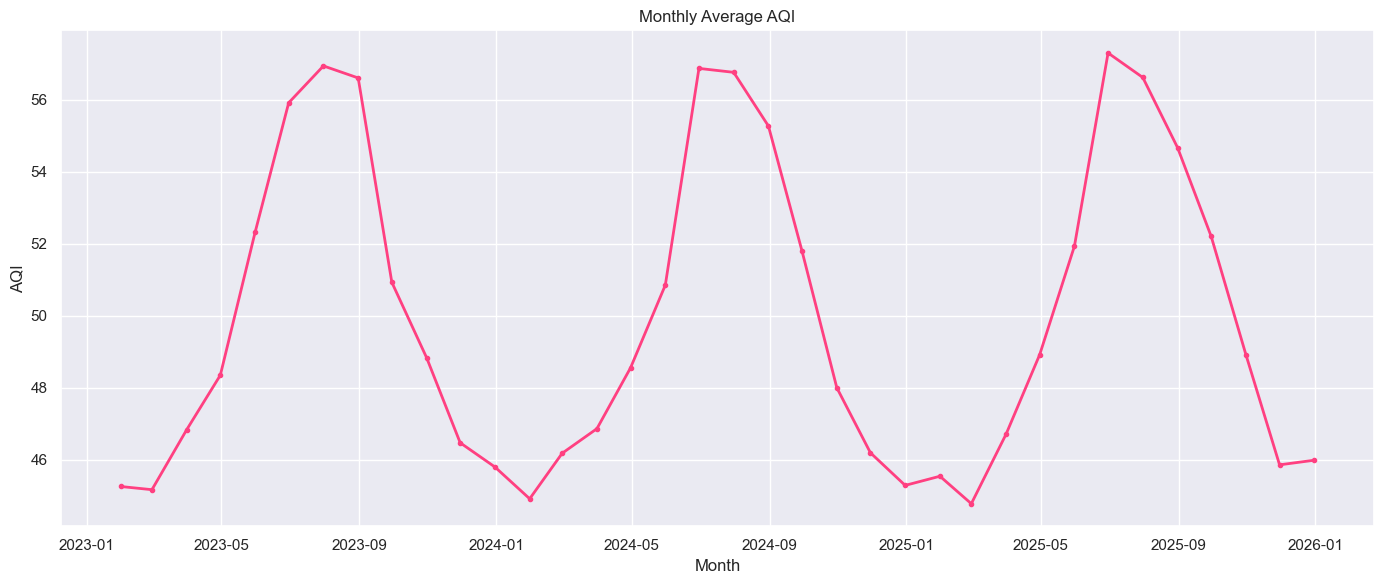

In [40]:
monthly_aqi = df.set_index("timestamp")["synthetic_aqi"].resample("ME").mean()
plt.figure(figsize=(14, 6))
plt.plot(monthly_aqi.index, monthly_aqi.values, marker="o", markersize=3, color="#FF4081", linewidth=2)
plt.title("Monthly Average AQI")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.tight_layout()

- **AQI by district**

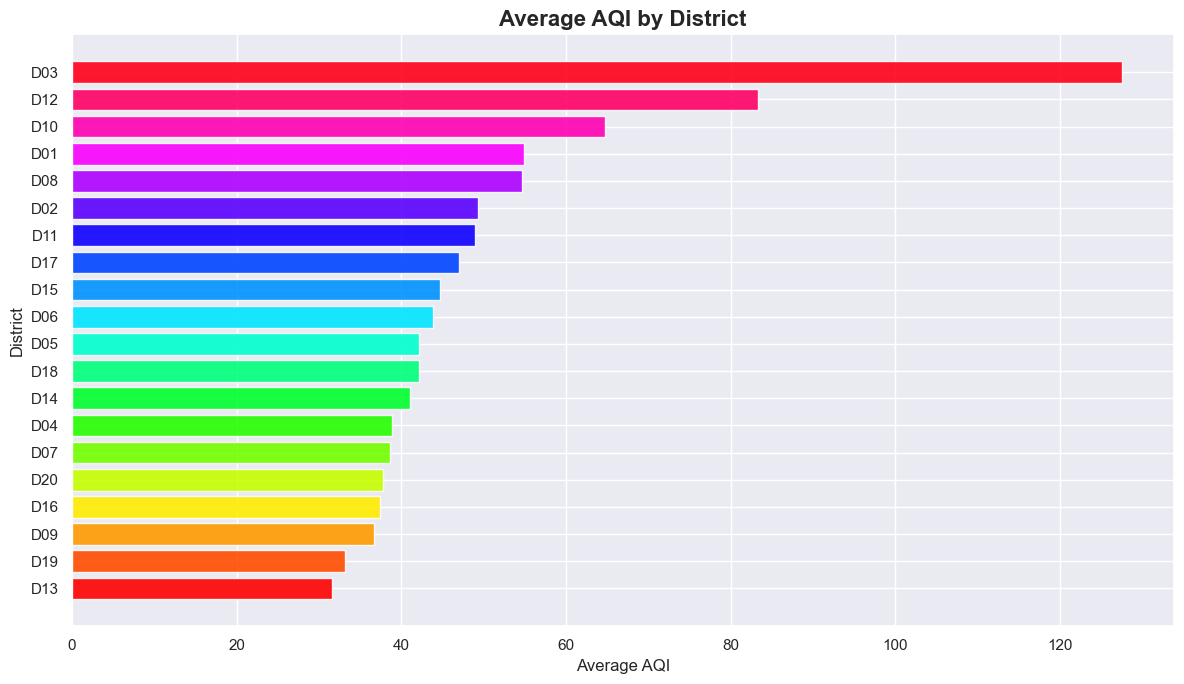

In [41]:

district_aqi = df.groupby("district_id")["synthetic_aqi"].mean().sort_values()

colors = plt.cm.hsv(np.linspace(0, 1, len(district_aqi)))

plt.figure(figsize=(12, 7))

plt.barh(
    district_aqi.index,
    district_aqi.values,
    color=colors,
    alpha=0.9
)

plt.title("Average AQI by District", fontsize=16, fontweight="bold")
plt.xlabel("Average AQI")
plt.ylabel("District")
plt.tight_layout()
plt.show()

- **PM2.5 by district**

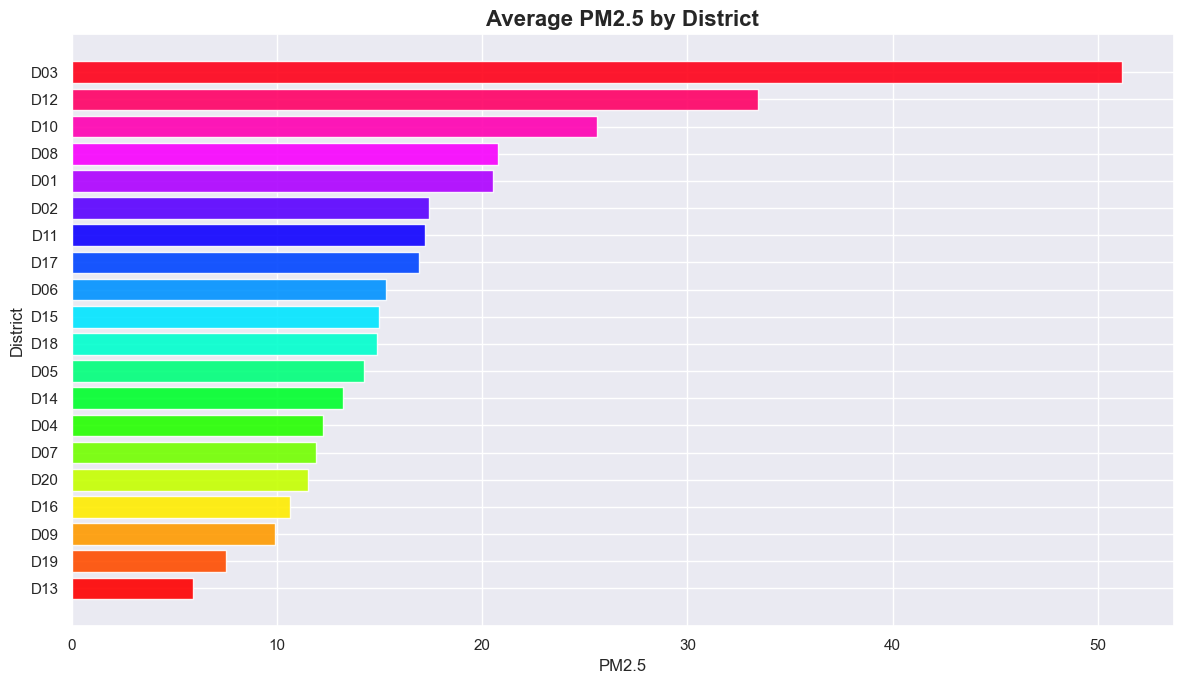

In [42]:

district_pm25 = df.groupby("district_id")["pm25"].mean().sort_values()

plt.figure(figsize=(12, 7))

colors = plt.cm.hsv(
    np.linspace(0, 1, len(district_pm25))
)

plt.barh(
    district_pm25.index,
    district_pm25.values,
    color=colors,
    alpha=0.9
)

plt.title("Average PM2.5 by District", fontsize=16, fontweight="bold")
plt.xlabel("PM2.5")
plt.ylabel("District")

plt.tight_layout()
plt.show()

- **PM10 by district**

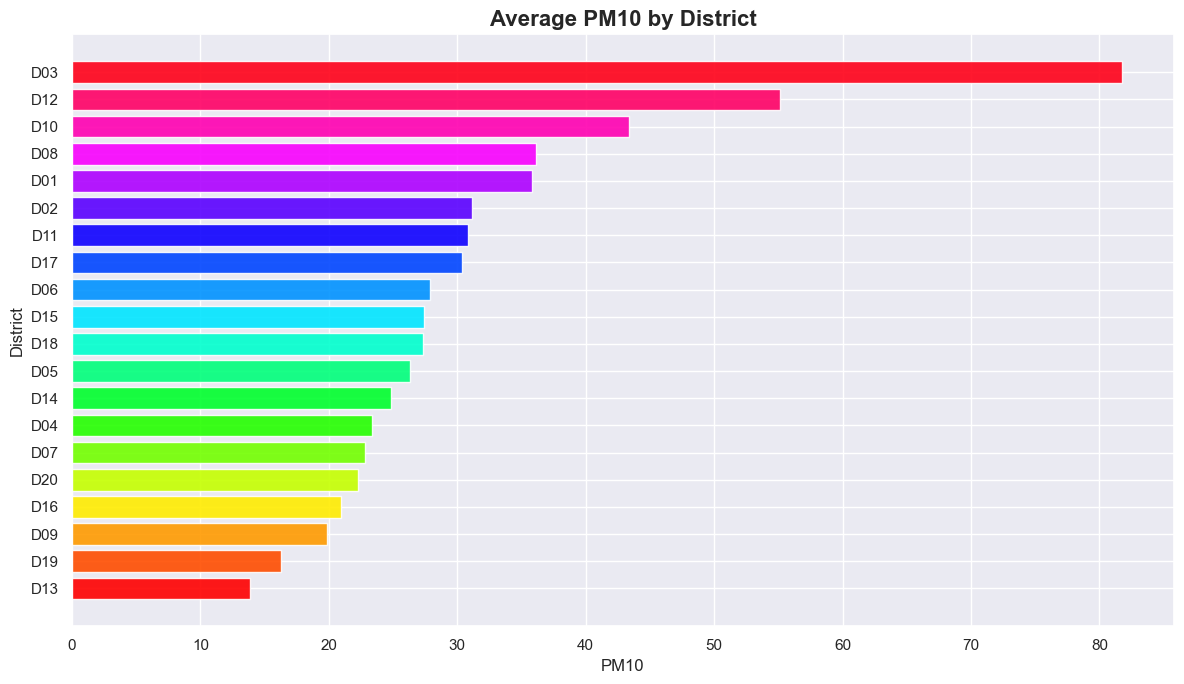

In [43]:
# 32. Average PM10 by District
district_pm10 = df.groupby("district_id")["pm10"].mean().sort_values()

plt.figure(figsize=(12, 7))

colors = plt.cm.hsv(
    np.linspace(0, 1, len(district_pm10))
)

plt.barh(
    district_pm10.index,
    district_pm10.values,
    color=colors,
    alpha=0.9
)

plt.title("Average PM10 by District", fontsize=16, fontweight="bold")
plt.xlabel("PM10")
plt.ylabel("District")

plt.tight_layout()
plt.show()

- **NO2 by district**

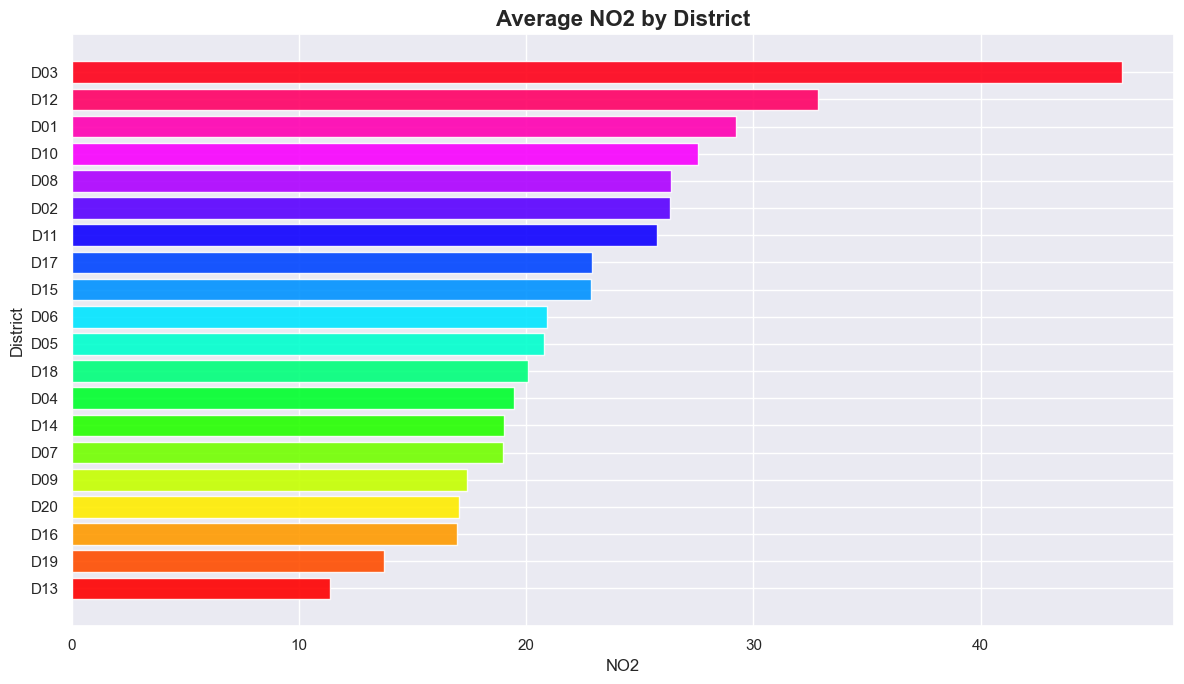

In [44]:
district_no2 = df.groupby("district_id")["no2"].mean().sort_values()

plt.figure(figsize=(12, 7))

colors = plt.cm.hsv(
    np.linspace(0, 1, len(district_no2))
)

plt.barh(
    district_no2.index,
    district_no2.values,
    color=colors,
    alpha=0.9
)

plt.title("Average NO2 by District", fontsize=16, fontweight="bold")
plt.xlabel("NO2")
plt.ylabel("District")

plt.tight_layout()

- **O3 by district**

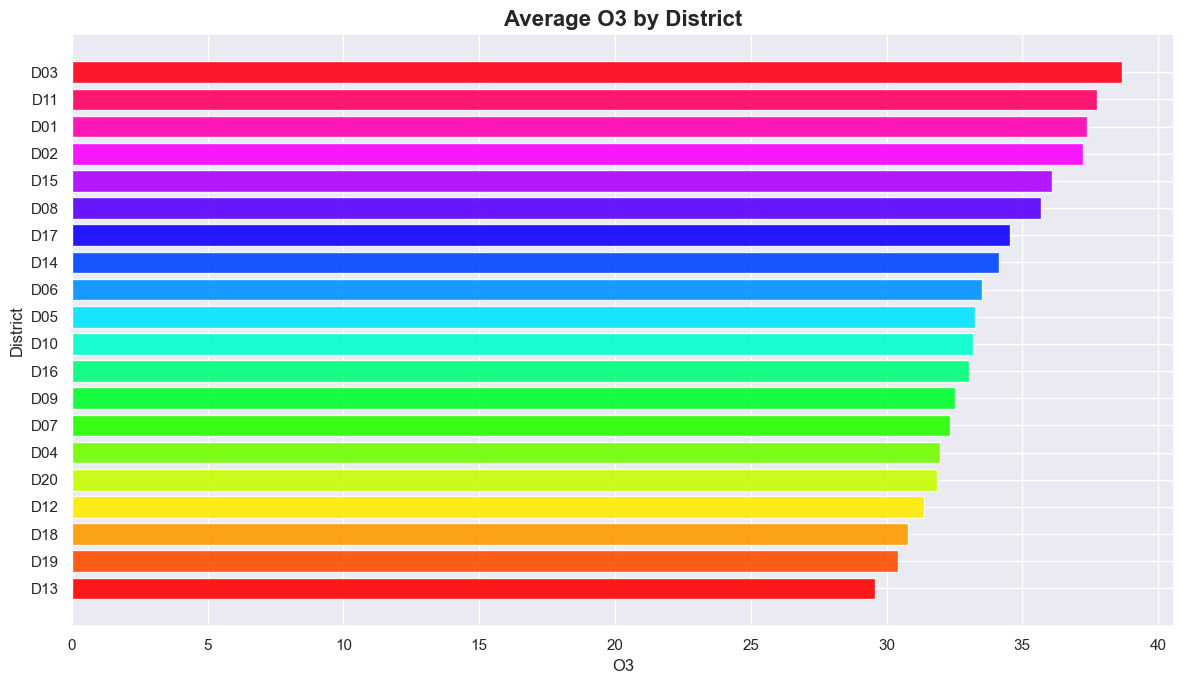

In [45]:
district_o3 = df.groupby("district_id")["o3"].mean().sort_values()

plt.figure(figsize=(12, 7))

colors = plt.cm.hsv(
    np.linspace(0, 1, len(district_o3))
)

plt.barh(
    district_o3.index,
    district_o3.values,
    color=colors,
    alpha=0.9
)

plt.title("Average O3 by District", fontsize=16, fontweight="bold")
plt.xlabel("O3")
plt.ylabel("District")

plt.tight_layout()

**CO by district**

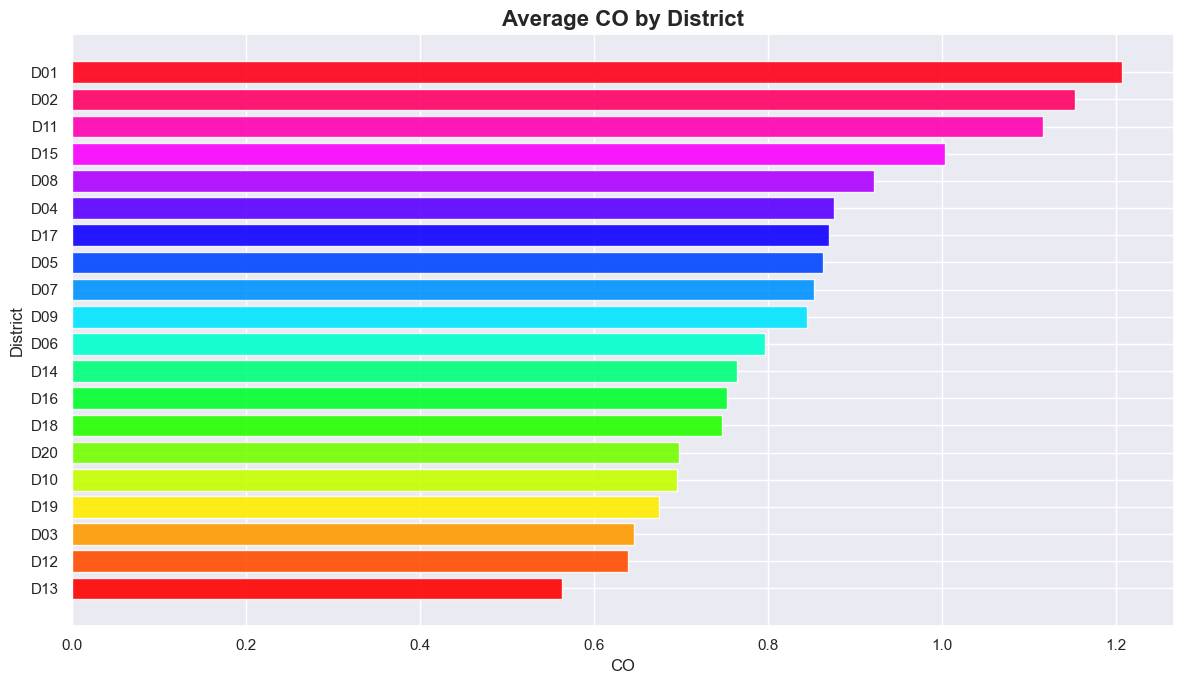

In [46]:
district_co = df.groupby("district_id")["co"].mean().sort_values()

plt.figure(figsize=(12, 7))

colors = plt.cm.hsv(
    np.linspace(0, 1, len(district_co))
)

plt.barh(
    district_co.index,
    district_co.values,
    color=colors,
    alpha=0.9
)

plt.title("Average CO by District", fontsize=16, fontweight="bold")
plt.xlabel("CO")
plt.ylabel("District")

plt.tight_layout()

- **AQI by hour**

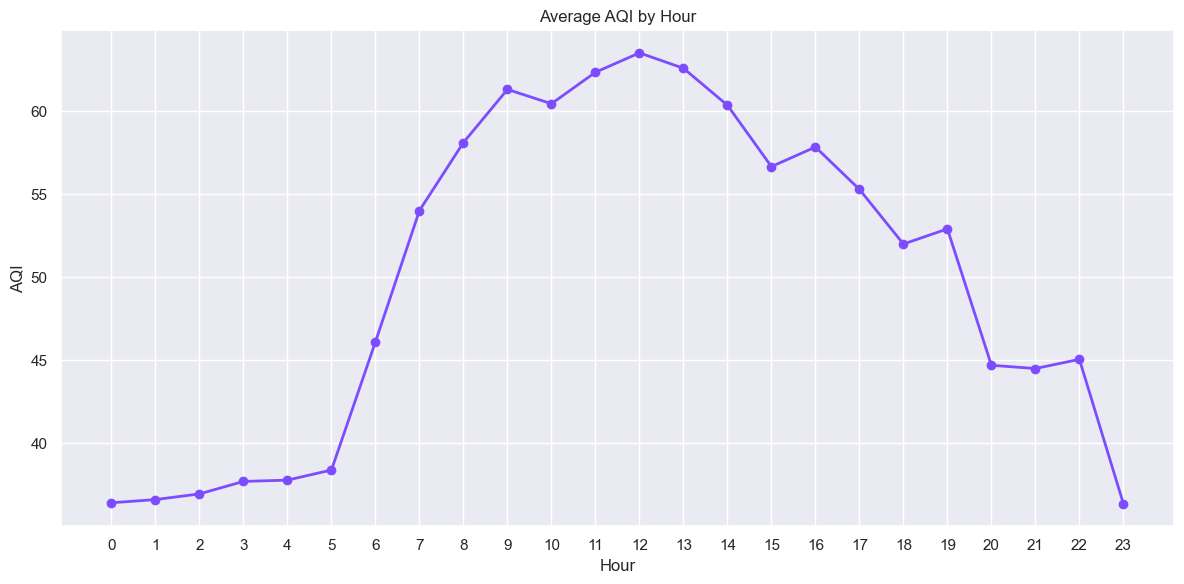

In [47]:
hour_aqi = df.groupby("hour")["synthetic_aqi"].mean()
plt.figure(figsize=(12, 6))
plt.plot(hour_aqi.index, hour_aqi.values, marker="o", color="#7C4DFF", linewidth=2)
plt.title("Average AQI by Hour")
plt.xlabel("Hour")
plt.ylabel("AQI")
plt.xticks(range(24))
plt.tight_layout()

- **AQI by month**

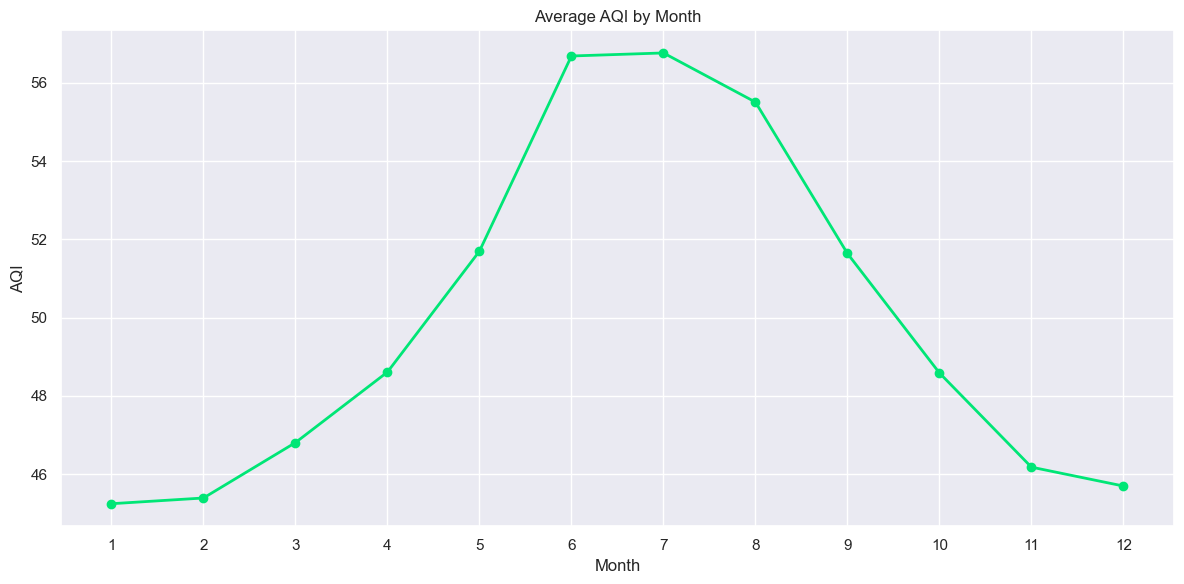

In [48]:
month_aqi = df.groupby("month")["synthetic_aqi"].mean()
plt.figure(figsize=(12, 6))
plt.plot(month_aqi.index, month_aqi.values, marker="o", color="#00E676", linewidth=2)
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.xticks(range(1, 13))
plt.tight_layout()

- **AQI by day of week**

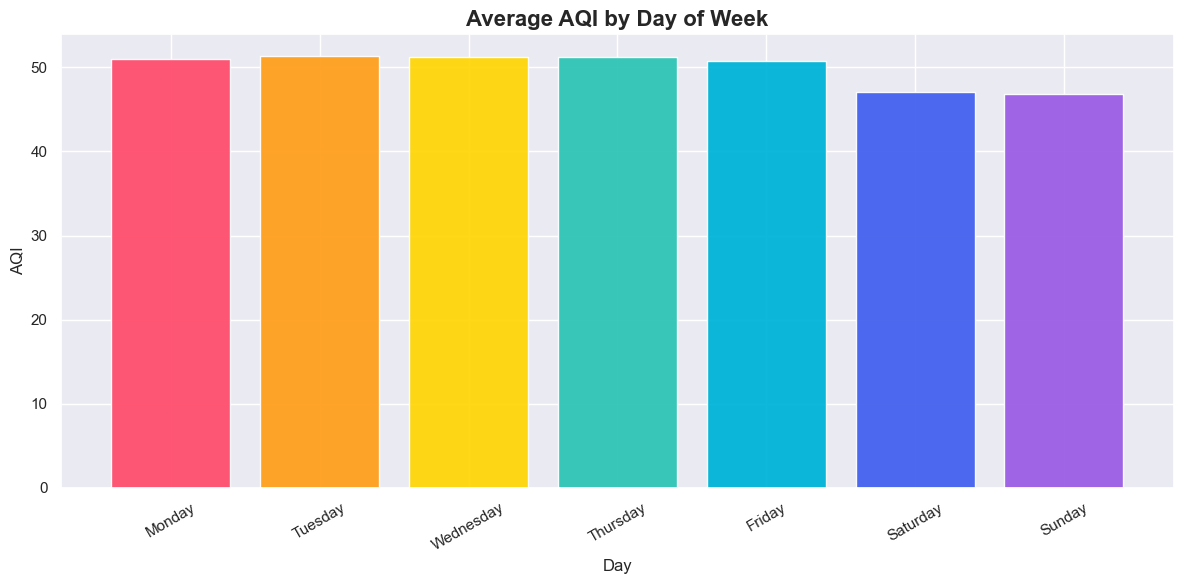

In [49]:
# 36. Average AQI by Day of Week

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_aqi = (
    df.groupby("day_name")["synthetic_aqi"]
    .mean()
    .reindex(day_order)
)

# Bright vibrant colors
colors = [
    "#FF4D6D",  # Pink Red
    "#FF9F1C",  # Orange
    "#FFD60A",  # Yellow
    "#2EC4B6",  # Teal
    "#00B4D8",  # Cyan
    "#4361EE",  # Blue
    "#9B5DE5"   # Purple
]

plt.figure(figsize=(12, 6))

plt.bar(
    day_aqi.index,
    day_aqi.values,
    color=colors,
    alpha=0.95
)

plt.title(
    "Average AQI by Day of Week",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day")
plt.ylabel("AQI")

plt.xticks(rotation=30)

plt.tight_layout()


- **AQI by year**

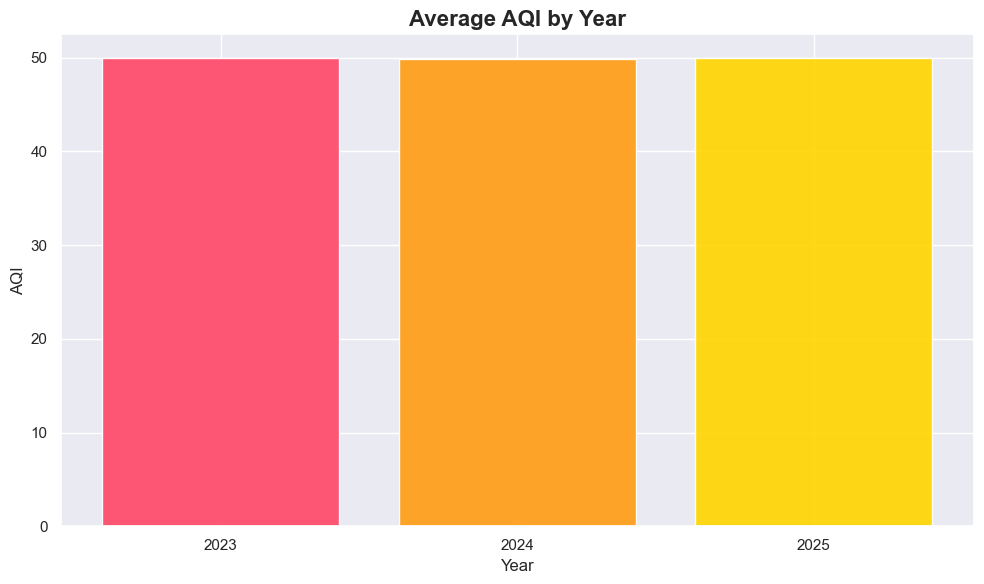

In [50]:
year_aqi = df.groupby("year")["synthetic_aqi"].mean()

colors = [
    "#FF4D6D",  # Pink Red
    "#FF9F1C",  # Orange
    "#FFD60A",  # Yellow
    "#2EC4B6",  # Teal
    "#00B4D8",  # Cyan
    "#4361EE",  # Blue
    "#9B5DE5"   # Purple
]

# Repeat colors automatically if there are more years
colors = (colors * ((len(year_aqi) // len(colors)) + 1))[:len(year_aqi)]

plt.figure(figsize=(10, 6))

plt.bar(
    year_aqi.index.astype(str),
    year_aqi.values,
    color=colors,
    alpha=0.95
)

plt.title("Average AQI by Year", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("AQI")

plt.tight_layout()

- **Category distribution**

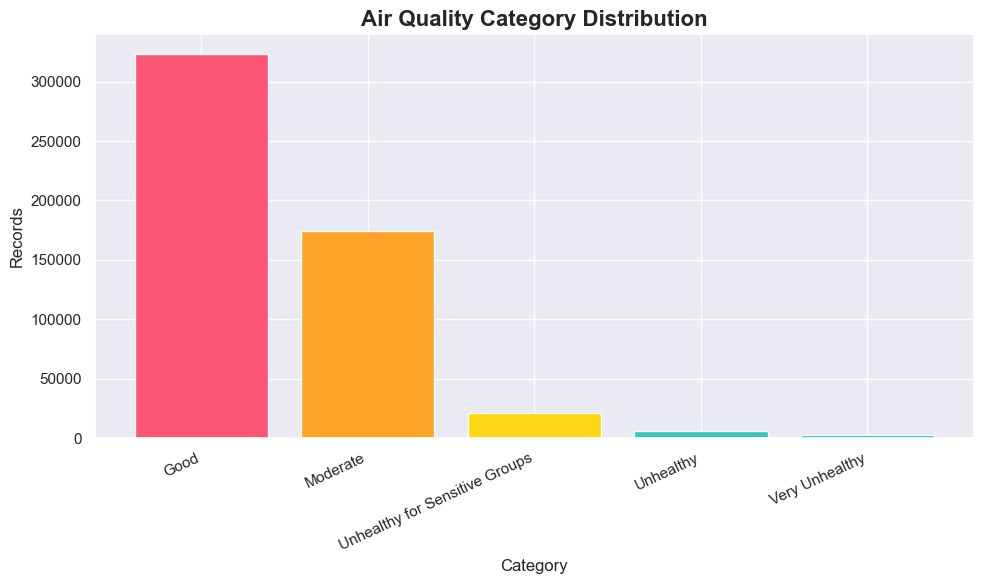

In [51]:
category_counts = df["air_quality_category"].value_counts()

colors = [
    "#FF4D6D",  # Pink Red
    "#FF9F1C",  # Orange
    "#FFD60A",  # Yellow
    "#2EC4B6",  # Teal
    "#00B4D8",  # Cyan
    "#4361EE",  # Blue
    "#9B5DE5"   # Purple
]

# Automatically repeat colors if categories are more than 7
colors = (
    colors * ((len(category_counts) // len(colors)) + 1)
)[:len(category_counts)]

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values,
    color=colors,
    alpha=0.95
)

plt.title(
    "Air Quality Category Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Records")

plt.xticks(rotation=25, ha="right")

plt.tight_layout()

- **Sensor status distribution**

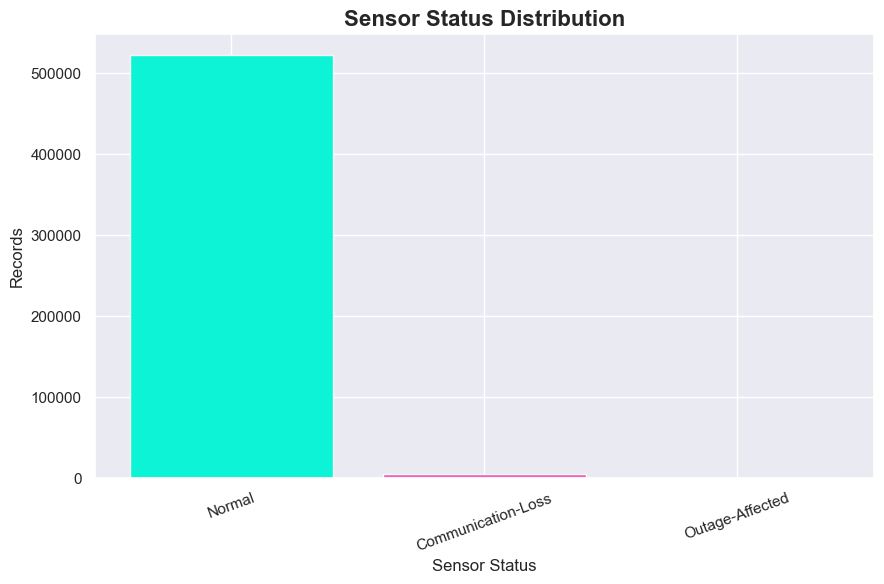

In [52]:
sensor_counts = df["sensor_status"].value_counts()

colors = [
    "#00F5D4",  # Aqua
    "#F15BB5",  # Hot Pink
    "#FEE440",  # Bright Yellow
    "#00BBF9",  # Sky Blue
    "#9B5DE5",  # Violet
    "#F8961E"   # Orange
]

# Repeat colors automatically if needed
colors = (
    colors * ((len(sensor_counts) // len(colors)) + 1)
)[:len(sensor_counts)]

plt.figure(figsize=(9, 6))

plt.bar(
    sensor_counts.index,
    sensor_counts.values,
    color=colors,
    alpha=0.95
)

plt.title(
    "Sensor Status Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sensor Status")
plt.ylabel("Records")

plt.xticks(rotation=20)

plt.tight_layout()

- **Pollution alerts by year**

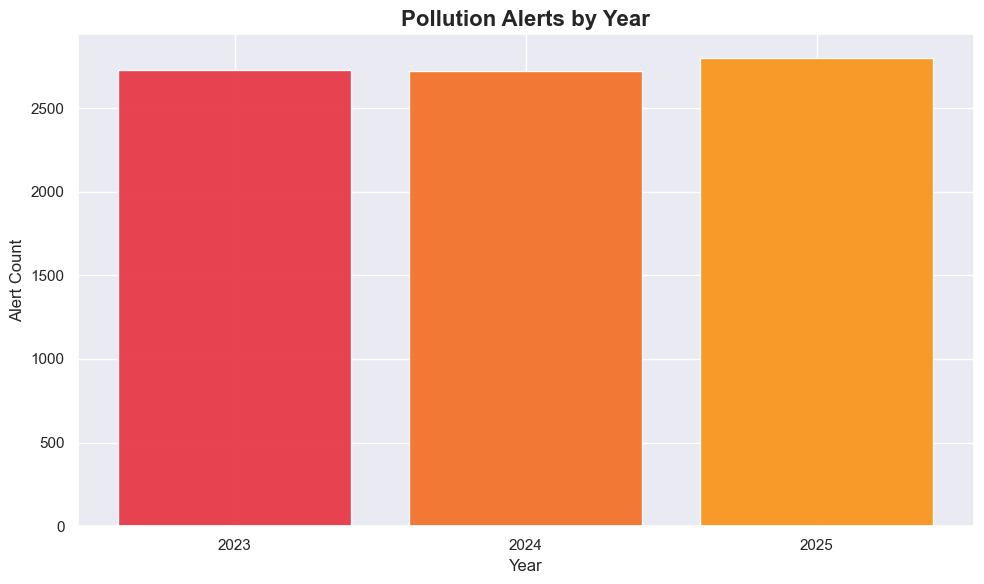

In [53]:
alerts_year = df.groupby("year")["pollution_alert_flag"].sum()

colors = [
    "#E63946",  # Red
    "#F3722C",  # Orange
    "#F8961E",  # Amber
    "#F9C74F",  # Gold
    "#90BE6D",  # Green
    "#43AA8B",  # Teal
    "#577590"   # Blue
]

# Repeat colors automatically if needed
colors = (
    colors * ((len(alerts_year) // len(colors)) + 1)
)[:len(alerts_year)]

plt.figure(figsize=(10, 6))

plt.bar(
    alerts_year.index.astype(str),
    alerts_year.values,
    color=colors,
    alpha=0.95
)

plt.title(
    "Pollution Alerts by Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Alert Count")

plt.tight_layout()


- **AQI box plot**

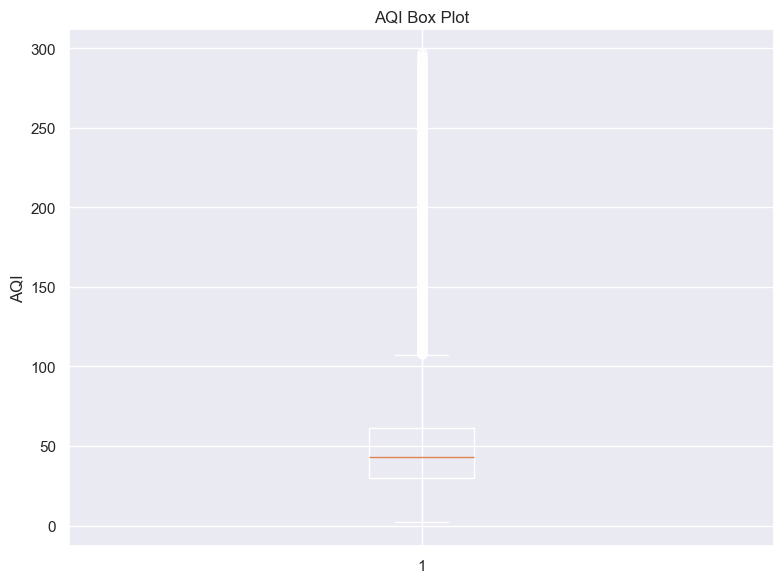

In [54]:
plt.figure(figsize=(8, 6))
plt.boxplot(df["synthetic_aqi"].dropna(), vert=True)
plt.title("AQI Box Plot")
plt.ylabel("AQI")
plt.tight_layout()

- **PM2.5 box plot**

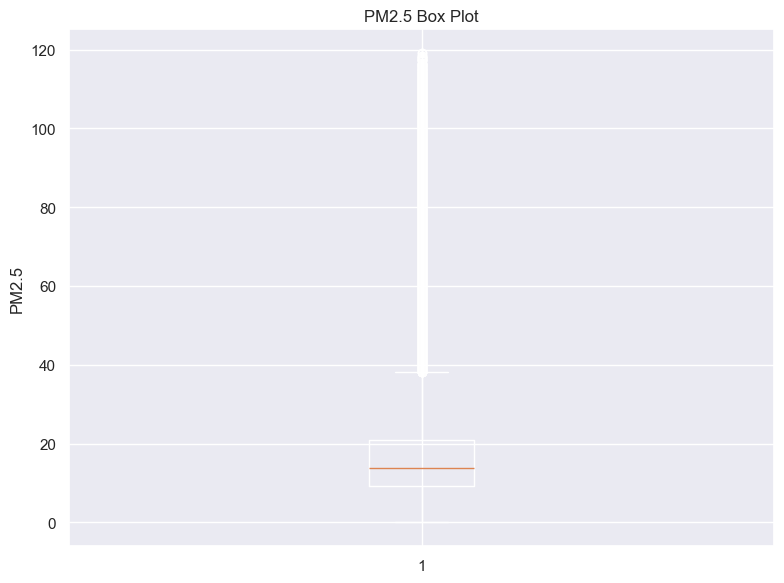

In [55]:
plt.figure(figsize=(8, 6))
plt.boxplot(df["pm25"].dropna(), vert=True)
plt.title("PM2.5 Box Plot")
plt.ylabel("PM2.5")
plt.tight_layout()

- **All pollutant distributions**

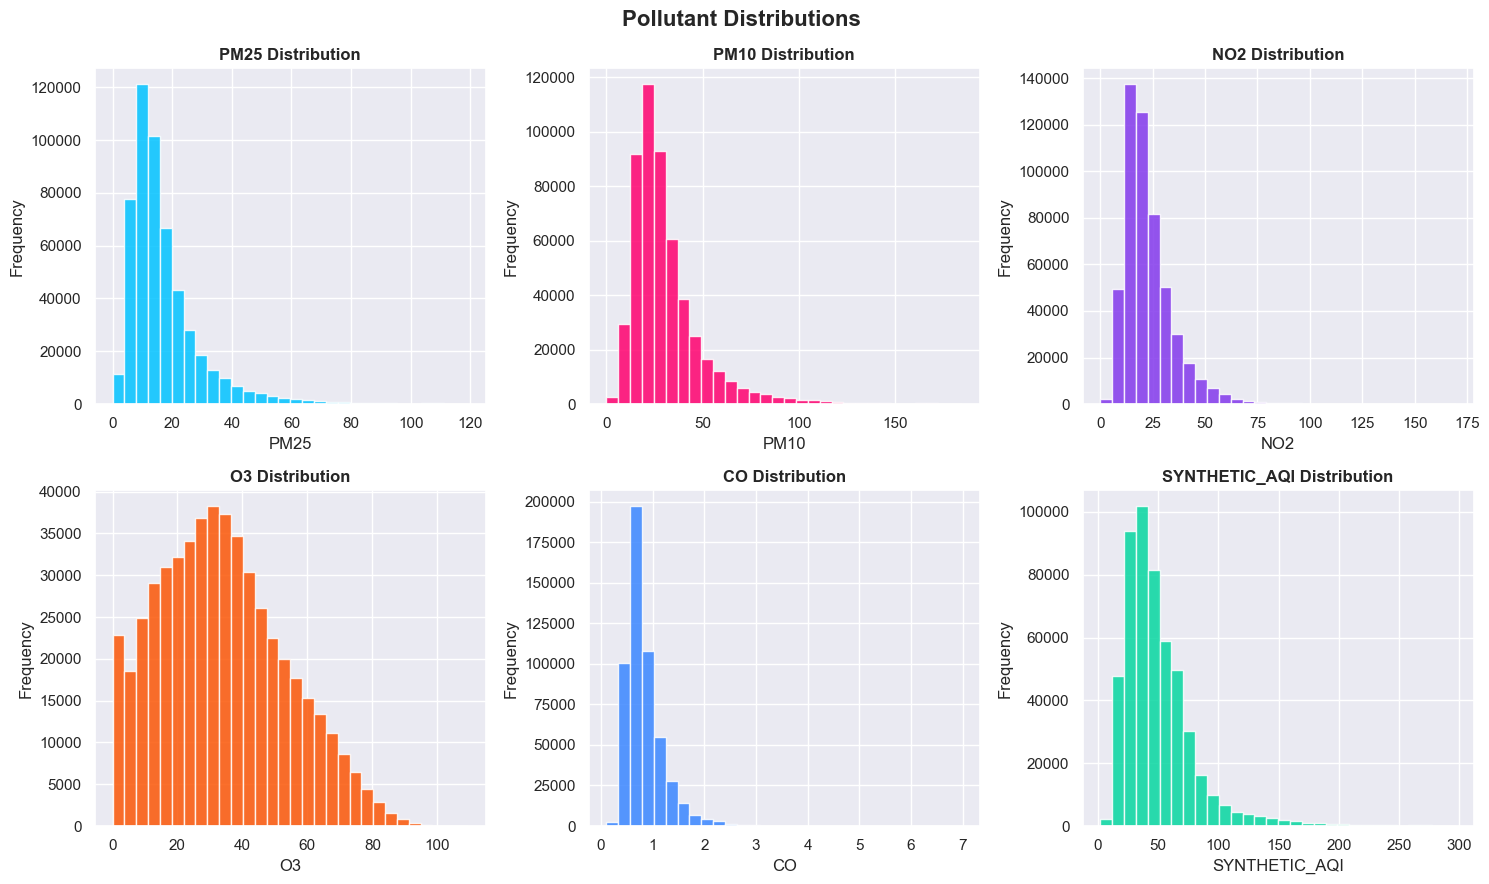

In [56]:
colors = [
    "#00C2FF",  # Cyan
    "#FF006E",  # Pink
    "#8338EC",  # Purple
    "#FB5607",  # Orange
    "#3A86FF",  # Blue
    "#06D6A0"   # Green
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, (ax, col) in enumerate(zip(axes.ravel(), numeric_cols)):
    ax.hist(
        df[col].dropna(),
        bins=30,
        color=colors[i % len(colors)],
        edgecolor="white",
        alpha=0.85
    )

    ax.set_title(f"{col.upper()} Distribution", fontsize=12, fontweight="bold")
    ax.set_xlabel(col.upper())
    ax.set_ylabel("Frequency")

# Hide unused subplot
for ax in axes.ravel()[len(numeric_cols):]:
    ax.axis("off")

fig.suptitle(
    "Pollutant Distributions",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

- **AQI vs PM2.5 scatter**

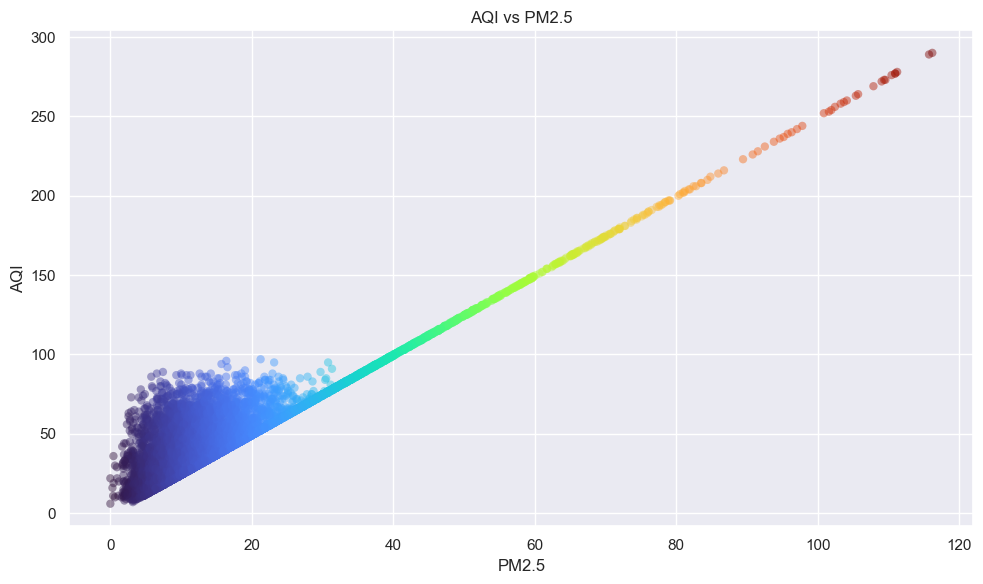

In [57]:
sample = df[["pm25", "synthetic_aqi"]].dropna().sample(min(10000, df.shape[0]), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample["pm25"], sample["synthetic_aqi"], c=sample["pm25"], cmap="turbo", alpha=0.45, edgecolors="none")
plt.title("AQI vs PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.tight_layout()

- **AQI vs PM10 scatter**

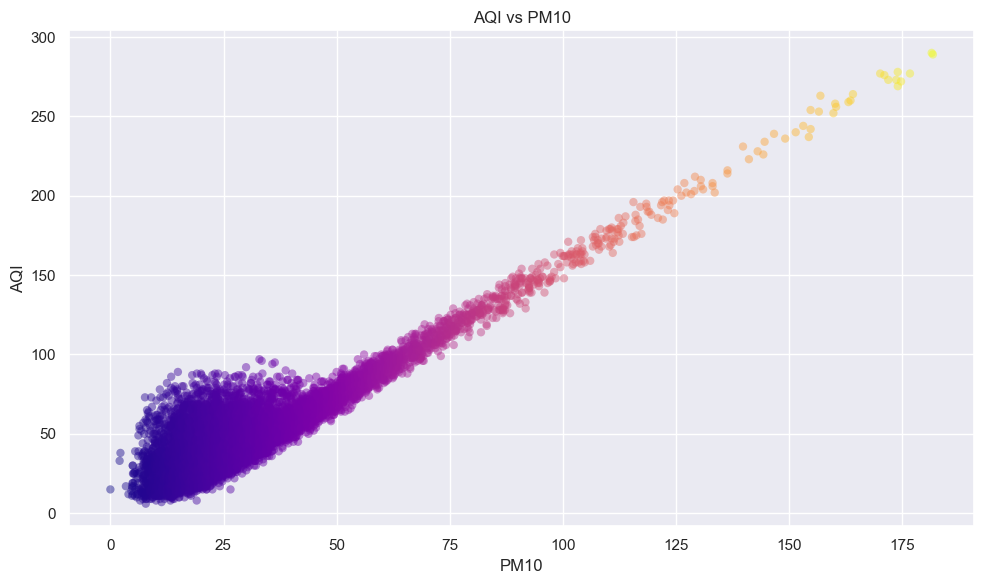

In [58]:
sample = df[["pm10", "synthetic_aqi"]].dropna().sample(min(10000, df.shape[0]), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample["pm10"], sample["synthetic_aqi"], c=sample["pm10"], cmap="plasma", alpha=0.45, edgecolors="none")
plt.title("AQI vs PM10")
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.tight_layout()

- **AQI vs NO2**

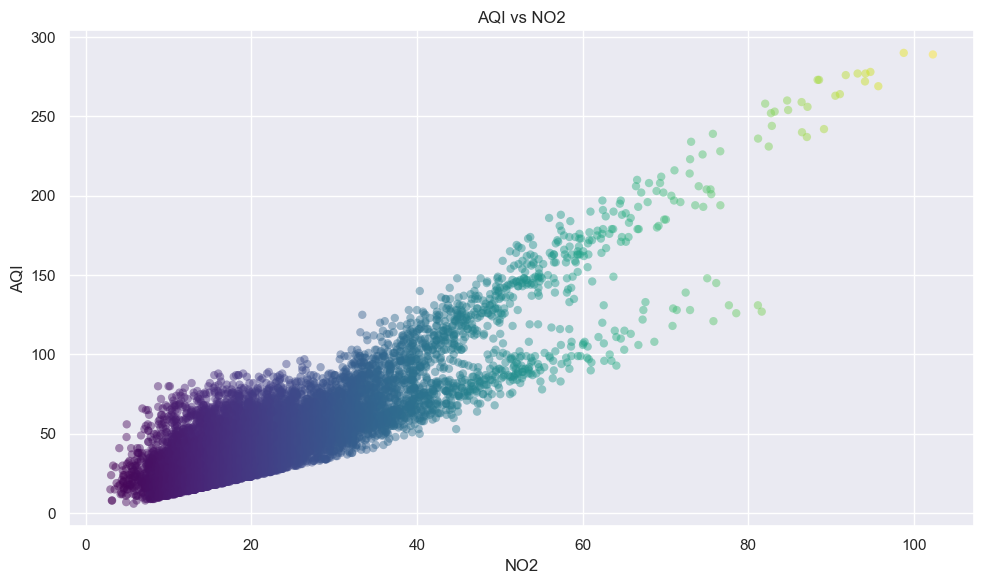

In [59]:
sample = df[["no2", "synthetic_aqi"]].dropna().sample(min(10000, df.shape[0]), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample["no2"], sample["synthetic_aqi"], c=sample["no2"], cmap="viridis", alpha=0.45, edgecolors="none")
plt.title("AQI vs NO2")
plt.xlabel("NO2")
plt.ylabel("AQI")
plt.tight_layout()

- **Average pollutants level**

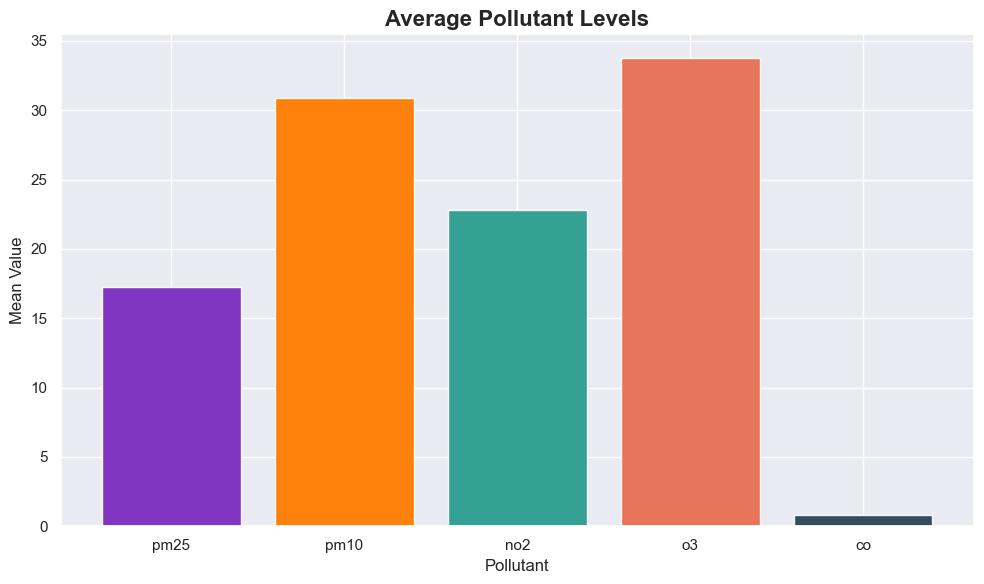

In [60]:
mean_values = df[pollutants].mean()

colors = [
    "#7B2CBF",  # Deep Purple
    "#FF7B00",  # Orange
    "#2A9D8F",  # Teal
    "#E76F51",  # Coral
    "#264653",  # Dark Blue
    "#E9C46A"   # Mustard
]

# Repeat colors automatically if needed
colors = (
    colors * ((len(mean_values) // len(colors)) + 1)
)[:len(mean_values)]

plt.figure(figsize=(10, 6))

plt.bar(
    mean_values.index,
    mean_values.values,
    color=colors,
    alpha=0.95
)

plt.title(
    "Average Pollutant Levels",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pollutant")
plt.ylabel("Mean Value")

plt.tight_layout()

- **Cumulative Pollution Alerts**

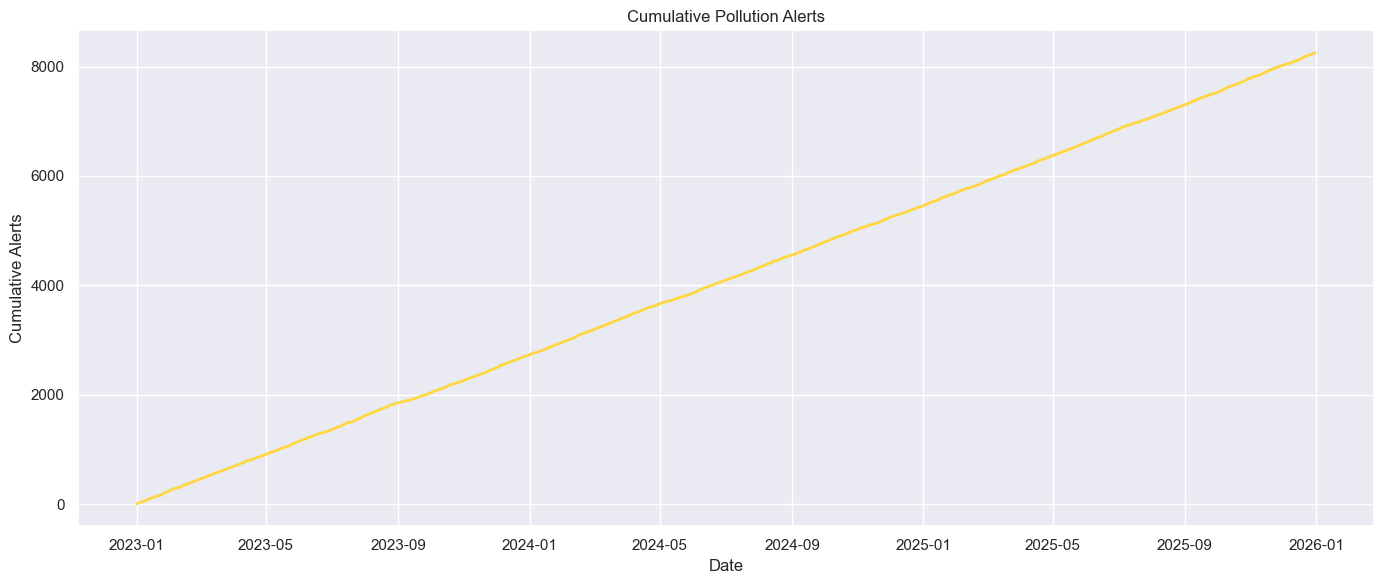

In [61]:
alerts_daily = df.set_index("timestamp")["pollution_alert_flag"].resample("D").sum().cumsum()
plt.figure(figsize=(14, 6))
plt.plot(alerts_daily.index, alerts_daily.values, color="#FFD740", linewidth=2)
plt.title("Cumulative Pollution Alerts")
plt.xlabel("Date")
plt.ylabel("Cumulative Alerts")
plt.tight_layout()

#### ***SEABORN***

- **AQI distribution**

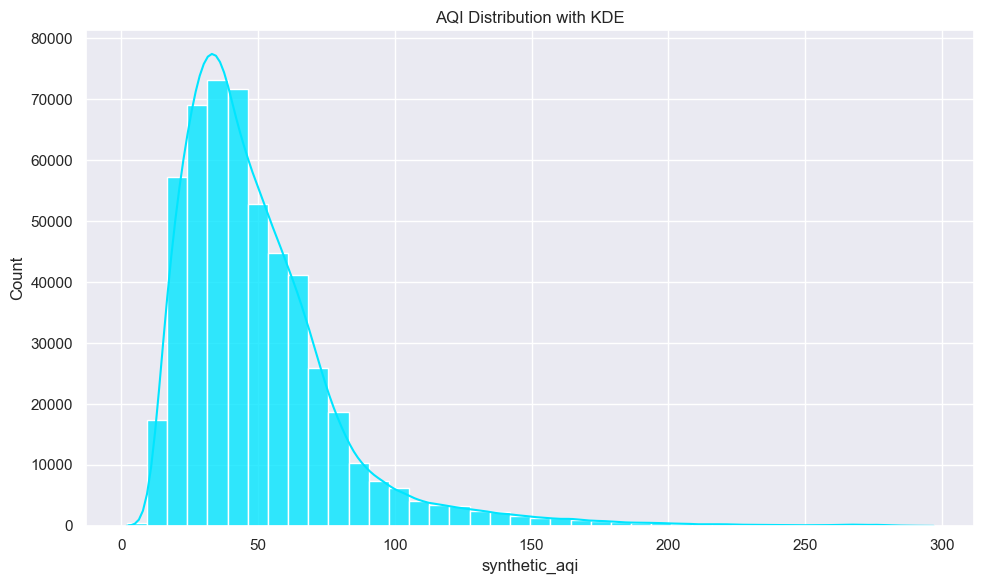

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="synthetic_aqi", bins=40, kde=True, color="#00E5FF", alpha=0.8)
plt.title("AQI Distribution with KDE")
plt.tight_layout()

- **PM2.5 distribution**

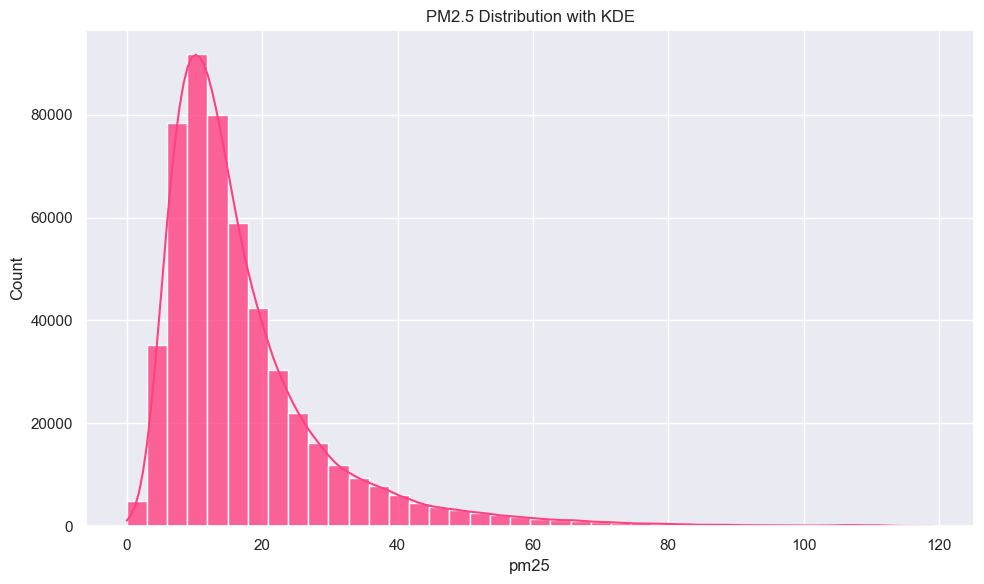

In [63]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="pm25", bins=40, kde=True, color="#FF4081", alpha=0.8)
plt.title("PM2.5 Distribution with KDE")
plt.tight_layout()

- **PM10 distribution**

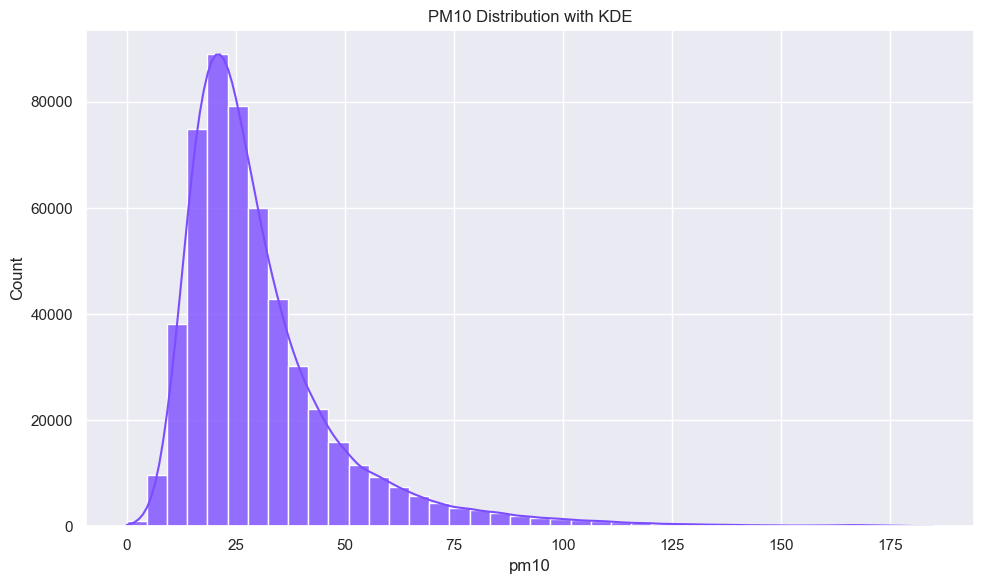

In [64]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="pm10", bins=40, kde=True, color="#7C4DFF", alpha=0.8)
plt.title("PM10 Distribution with KDE")
plt.tight_layout()

- **NO2 distribution**

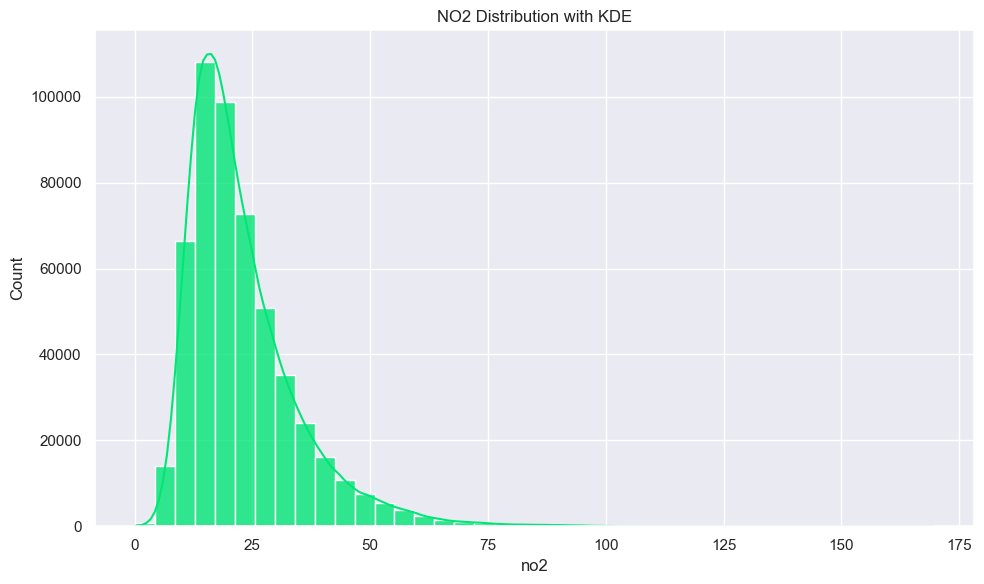

In [65]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="no2", bins=40, kde=True, color="#00E676", alpha=0.8)
plt.title("NO2 Distribution with KDE")
plt.tight_layout()

- **O3 distribution**

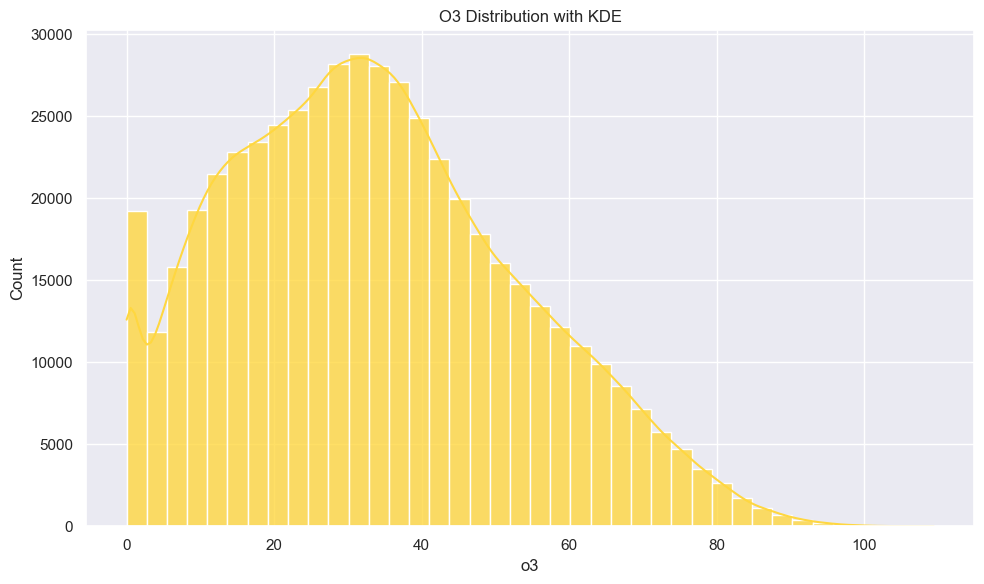

In [66]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="o3", bins=40, kde=True, color="#FFD740", alpha=0.8)
plt.title("O3 Distribution with KDE")
plt.tight_layout()

- **CO distribution**

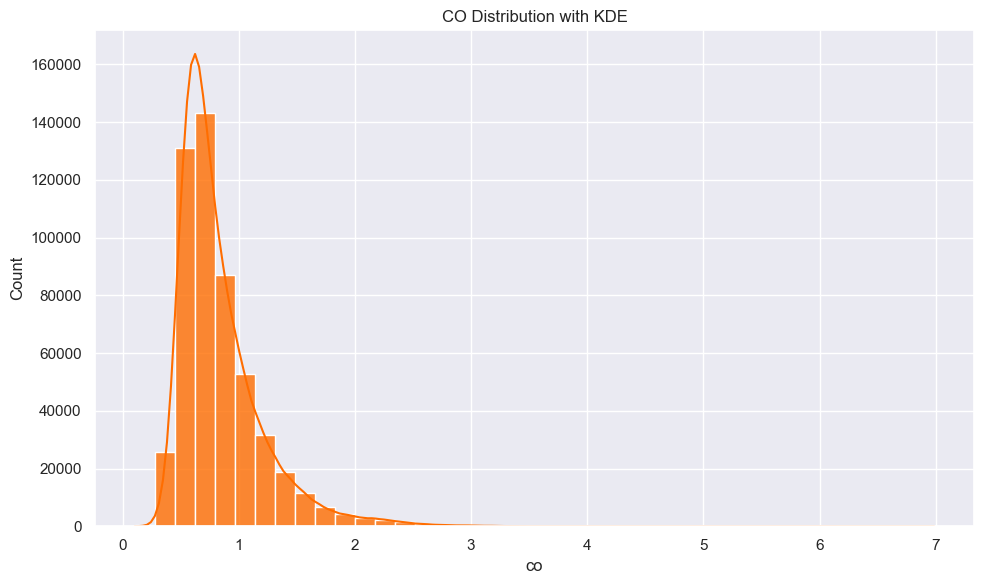

In [67]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="co", bins=40, kde=True, color="#FF6D00", alpha=0.8)
plt.title("CO Distribution with KDE")
plt.tight_layout()

- **AQI by category**

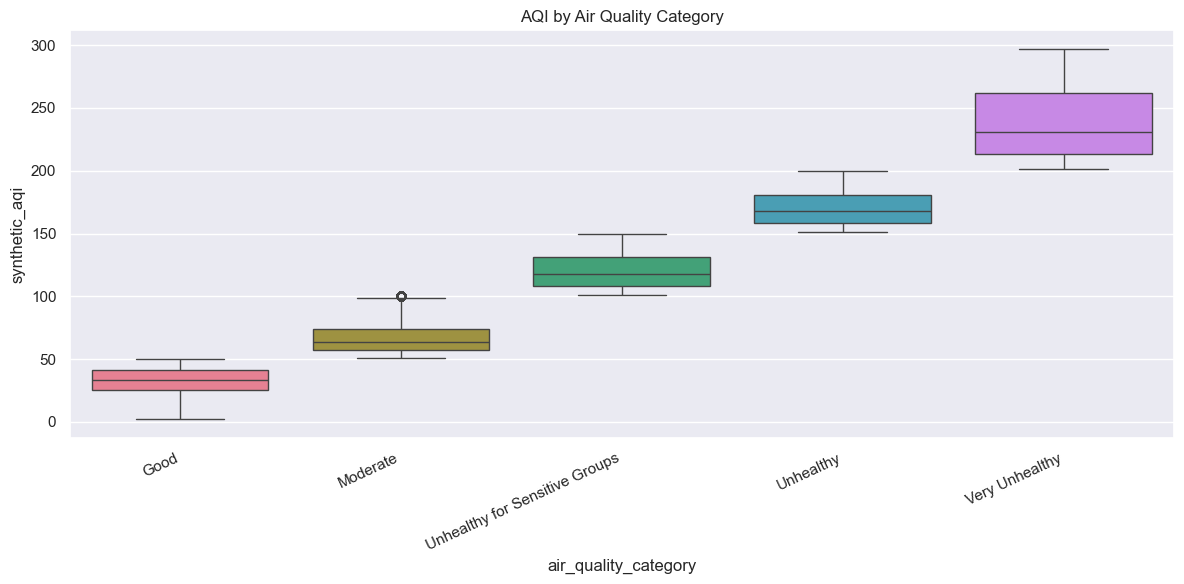

In [68]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="air_quality_category", y="synthetic_aqi", palette="husl", hue="air_quality_category", legend=False)
plt.title("AQI by Air Quality Category")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

- **PM2.5 by category**

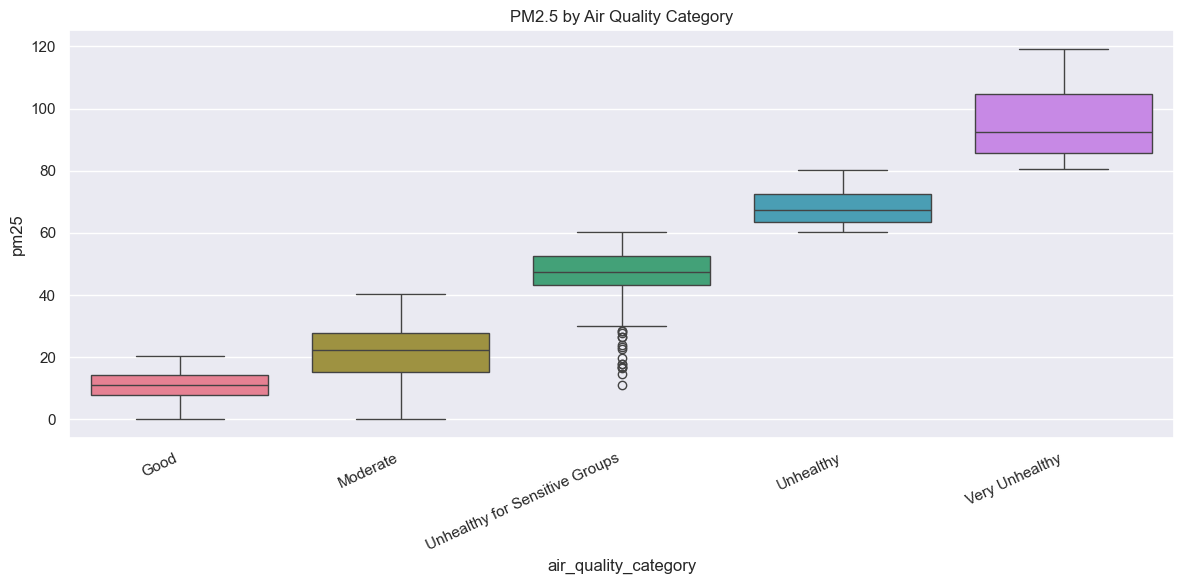

In [69]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="air_quality_category", y="pm25", palette="husl", hue="air_quality_category", legend=False)
plt.title("PM2.5 by Air Quality Category")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

- **PM10 by category**

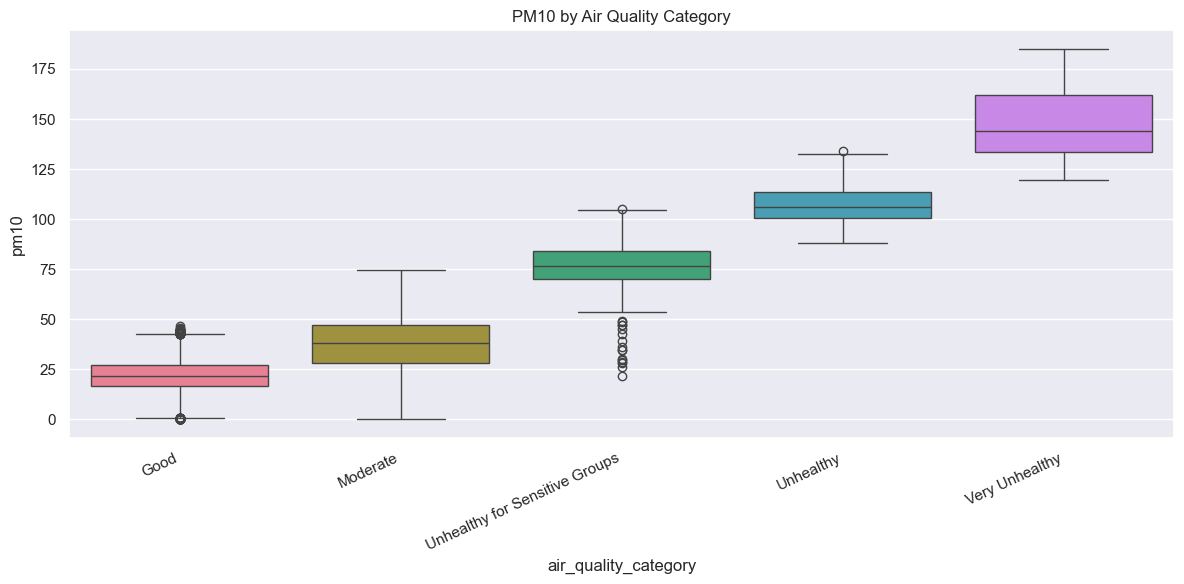

In [70]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="air_quality_category", y="pm10", palette="husl", hue="air_quality_category", legend=False)
plt.title("PM10 by Air Quality Category")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

- **AQI by sensor status**

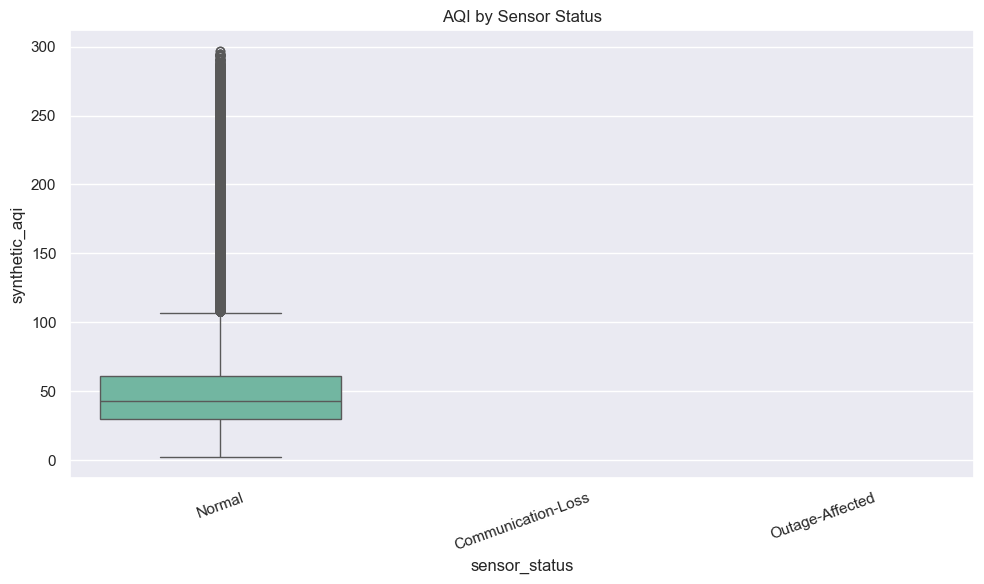

In [71]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="sensor_status", y="synthetic_aqi", palette="Set2", hue="sensor_status", legend=False)
plt.title("AQI by Sensor Status")
plt.xticks(rotation=20)
plt.tight_layout()

- **Average AQI by district**

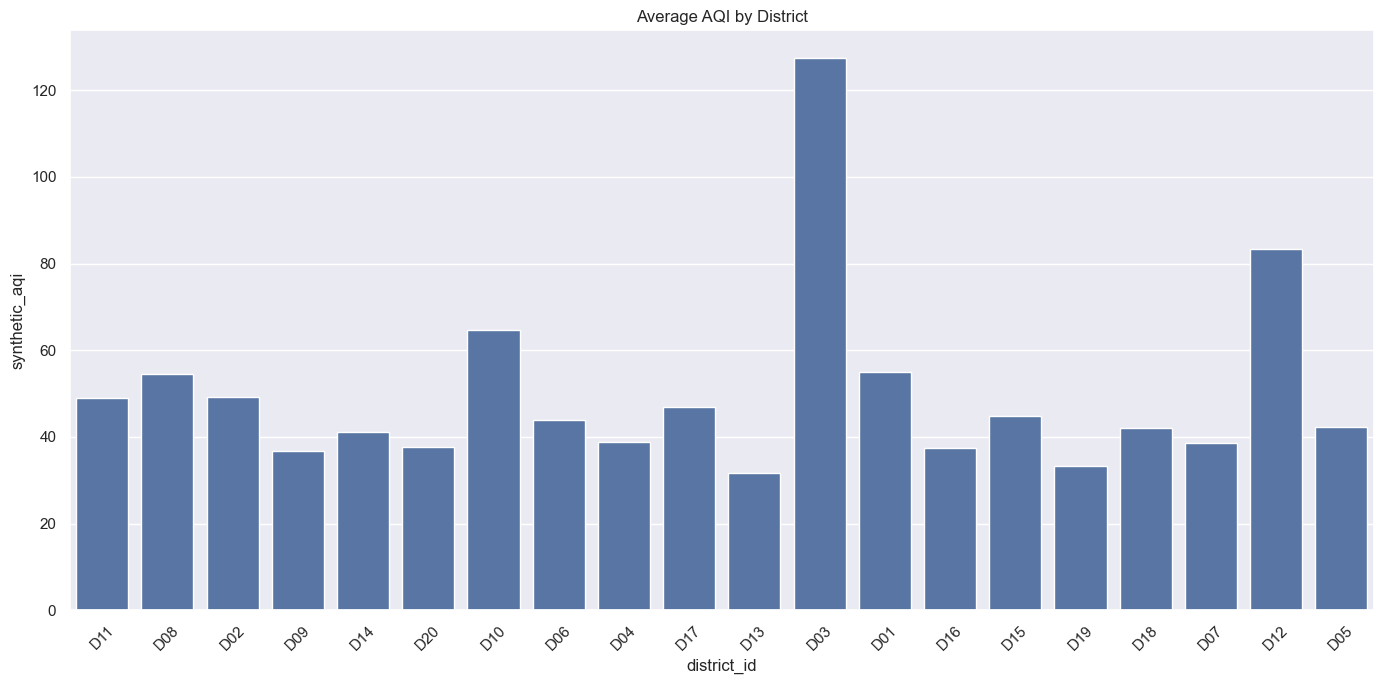

In [72]:
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df,
    x="district_id",
    y="synthetic_aqi",
    estimator="mean",
    errorbar=None
)
plt.title("Average AQI by District")
plt.xticks(rotation=45)
plt.tight_layout()

- **Average PM2.5 by district**

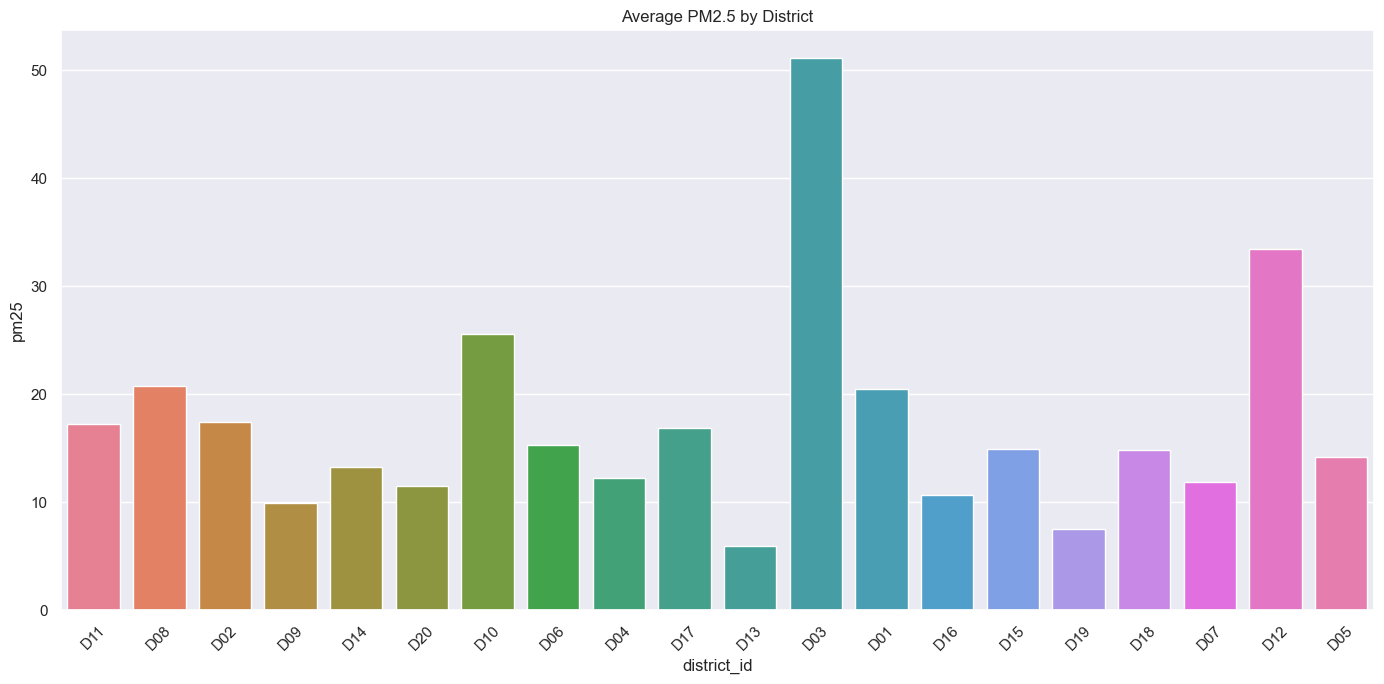

In [73]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df, x="district_id", y="pm25", estimator="mean", errorbar=None, palette="husl", hue="district_id", legend=False)
plt.title("Average PM2.5 by District")
plt.xticks(rotation=45)
plt.tight_layout()

- **Average PM10 by district**

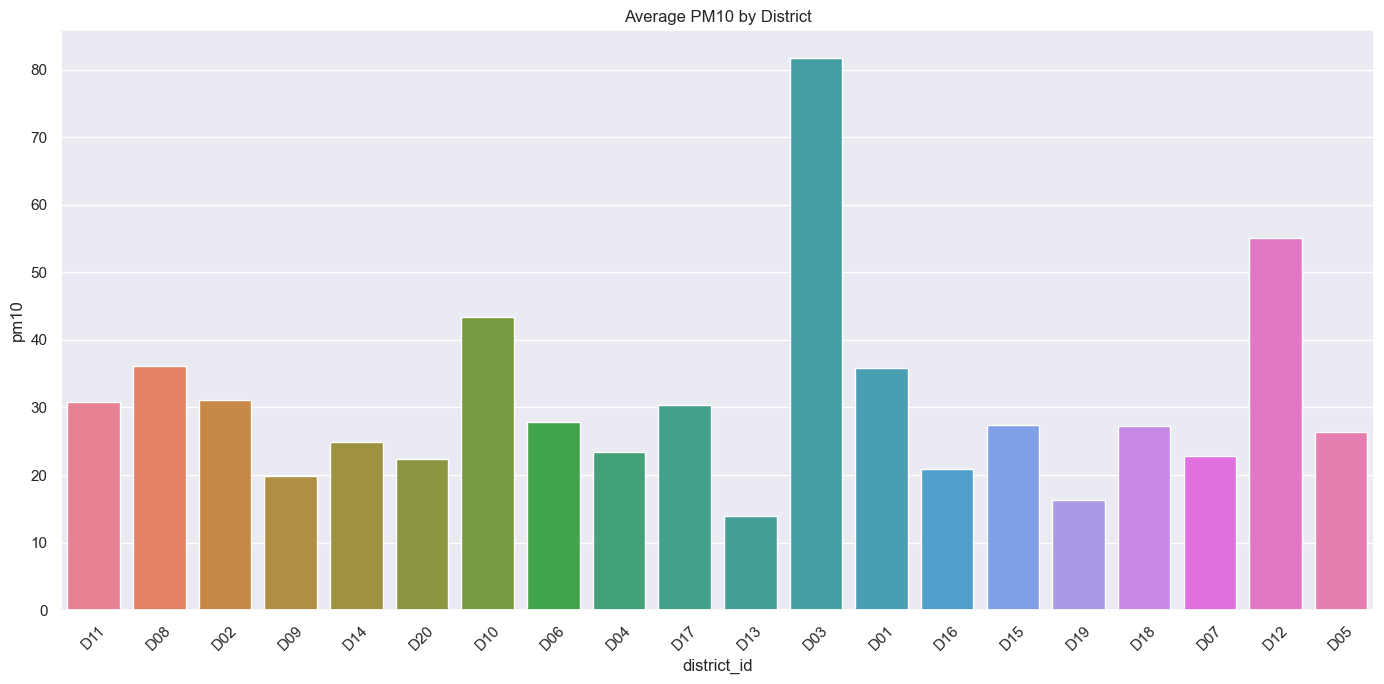

In [74]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df, x="district_id", y="pm10", estimator="mean", errorbar=None, palette="husl", hue="district_id", legend=False)
plt.title("Average PM10 by District")
plt.xticks(rotation=45)
plt.tight_layout()

- **AQI by hour**

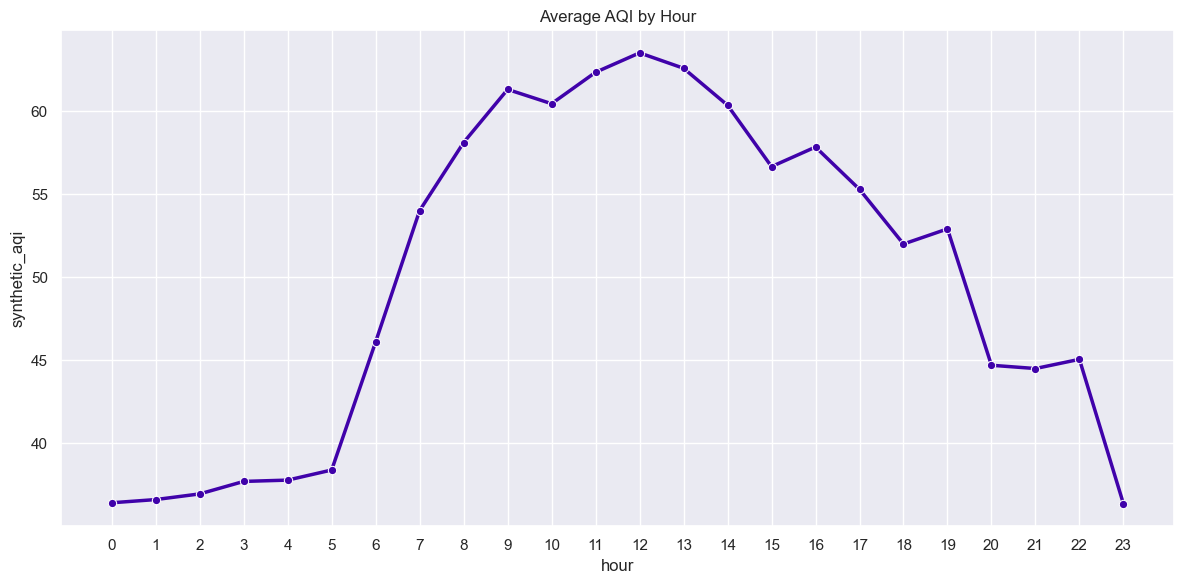

In [77]:
hour_data = df.groupby("hour", as_index=False)["synthetic_aqi"].mean()
plt.figure(figsize=(12, 6))
sns.lineplot(data=hour_data, x="hour", y="synthetic_aqi", marker="o", color="#4002AA", linewidth=2.5)
plt.title("Average AQI by Hour")
plt.xticks(range(24))
plt.tight_layout()

- **AQI by month**

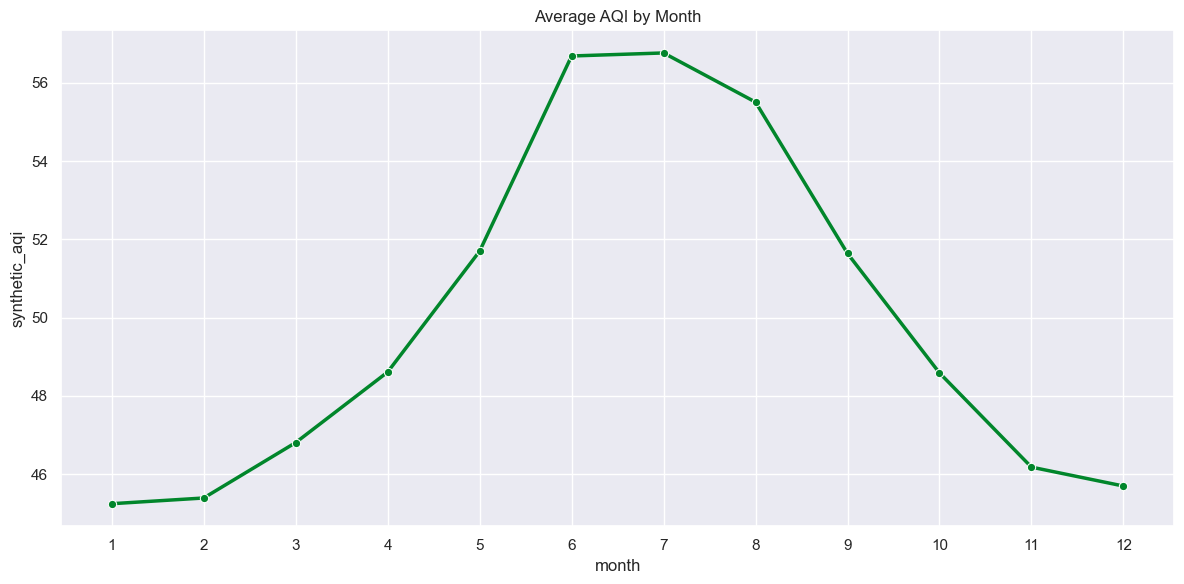

In [79]:
month_data = df.groupby("month", as_index=False)["synthetic_aqi"].mean()
plt.figure(figsize=(12, 6))
sns.lineplot(data=month_data, x="month", y="synthetic_aqi", marker="o", color="#01862B", linewidth=2.5)
plt.title("Average AQI by Month")
plt.xticks(range(1, 13))
plt.tight_layout()

- **AQI by year**


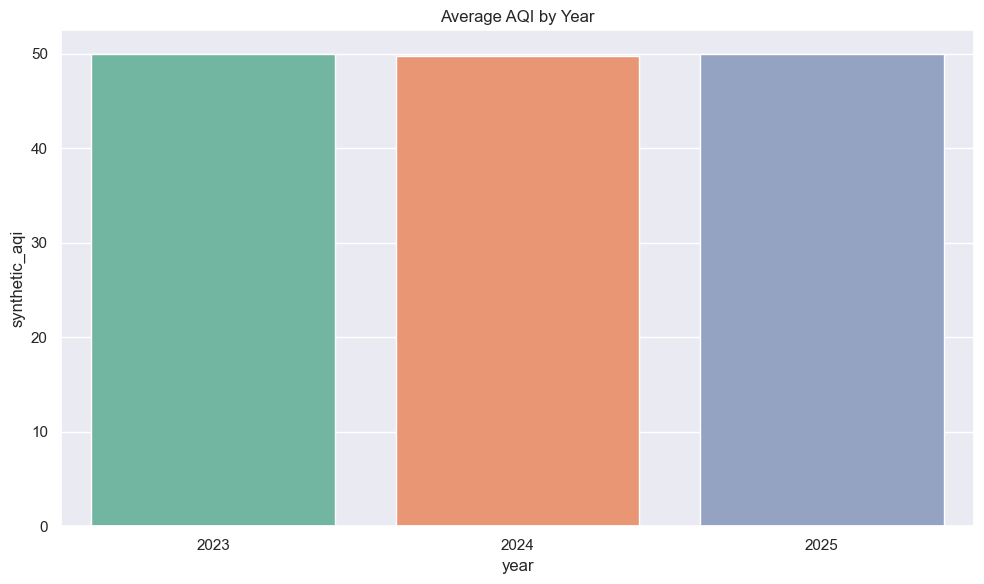

In [80]:
year_data = df.groupby("year", as_index=False)["synthetic_aqi"].mean()
plt.figure(figsize=(10, 6))
sns.barplot(data=year_data, x="year", y="synthetic_aqi", errorbar=None, palette="Set2", hue="year", legend=False)
plt.title("Average AQI by Year")
plt.tight_layout()

- **AQI vs PM2.5 regression**

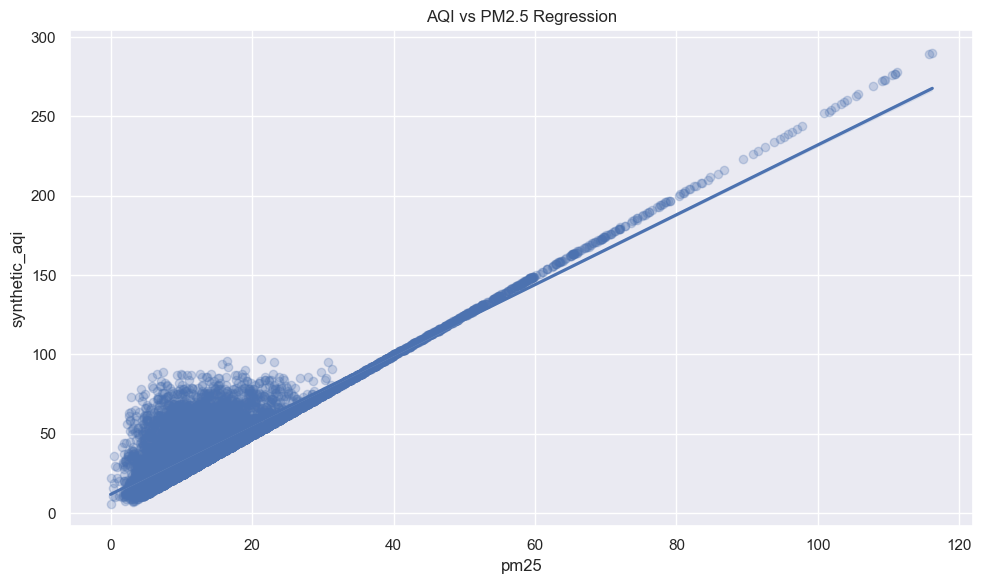

In [81]:
sample = df[["pm25", "synthetic_aqi"]].dropna().sample(min(10000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
sns.regplot(data=sample, x="pm25", y="synthetic_aqi", scatter_kws={"alpha": 0.25})
plt.title("AQI vs PM2.5 Regression")
plt.tight_layout()

- **AQI vs PM10 regression**

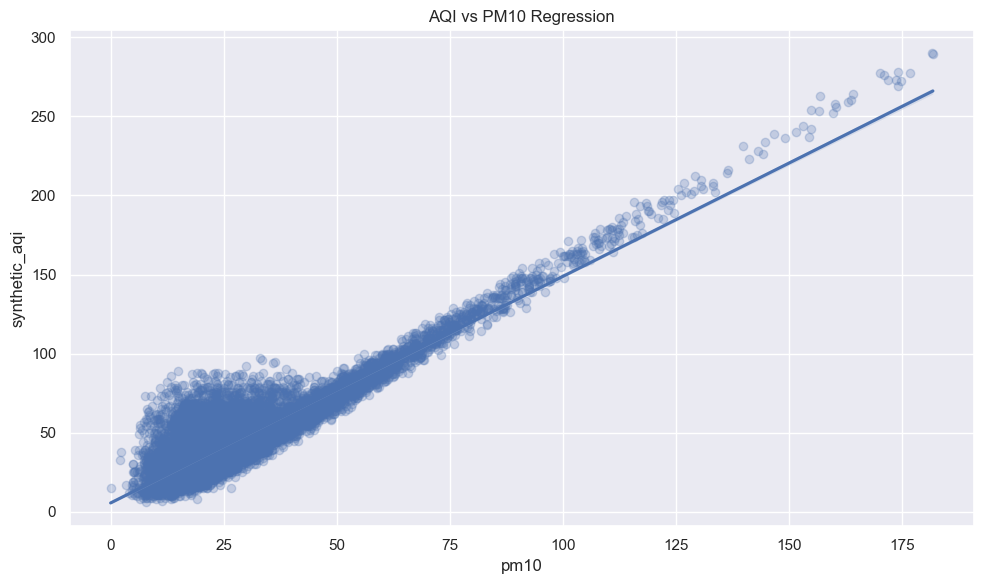

In [82]:
sample = df[["pm10", "synthetic_aqi"]].dropna().sample(min(10000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
sns.regplot(data=sample, x="pm10", y="synthetic_aqi", scatter_kws={"alpha": 0.25})
plt.title("AQI vs PM10 Regression")
plt.tight_layout()

- **AQI vs NO2 regression**

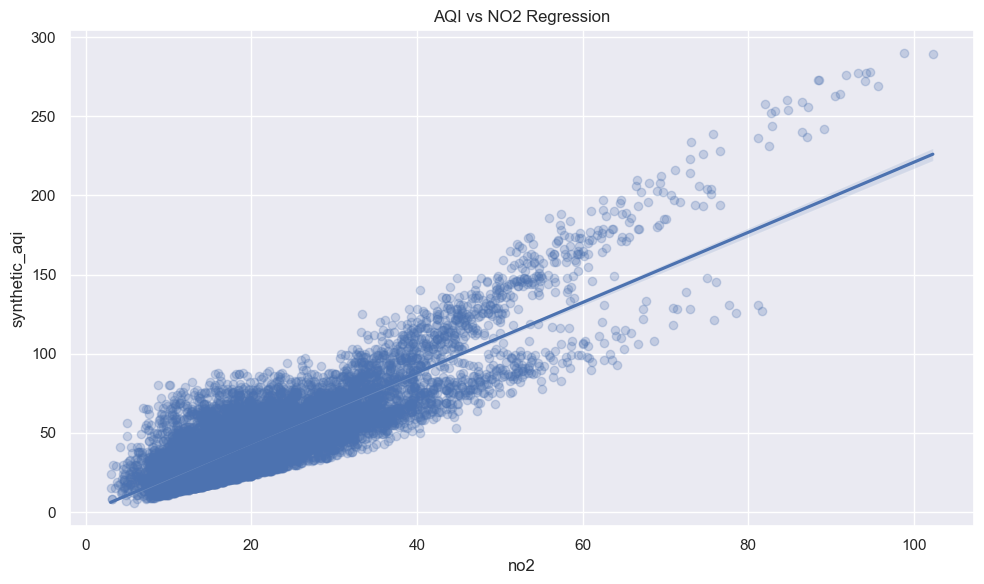

In [83]:
sample = df[["no2", "synthetic_aqi"]].dropna().sample(min(10000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
sns.regplot(data=sample, x="no2", y="synthetic_aqi", scatter_kws={"alpha": 0.25})
plt.title("AQI vs NO2 Regression")
plt.tight_layout()

- **Pollutant correlation heatmap**

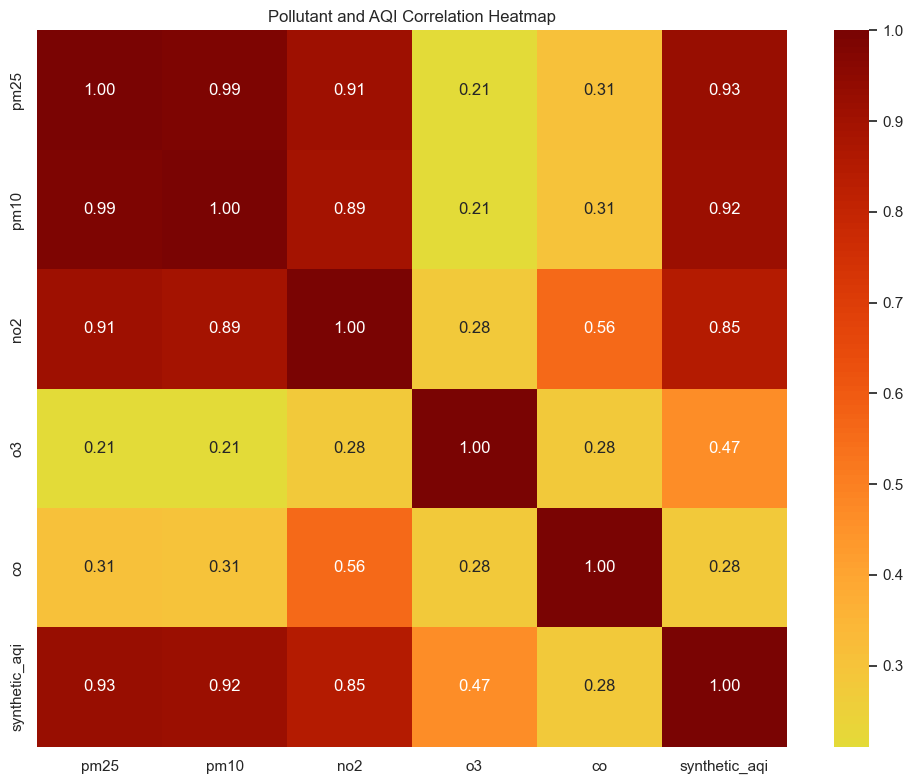

In [84]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="turbo", center=0)
plt.title("Pollutant and AQI Correlation Heatmap")
plt.tight_layout()

-  **District vs AQI heatmap**

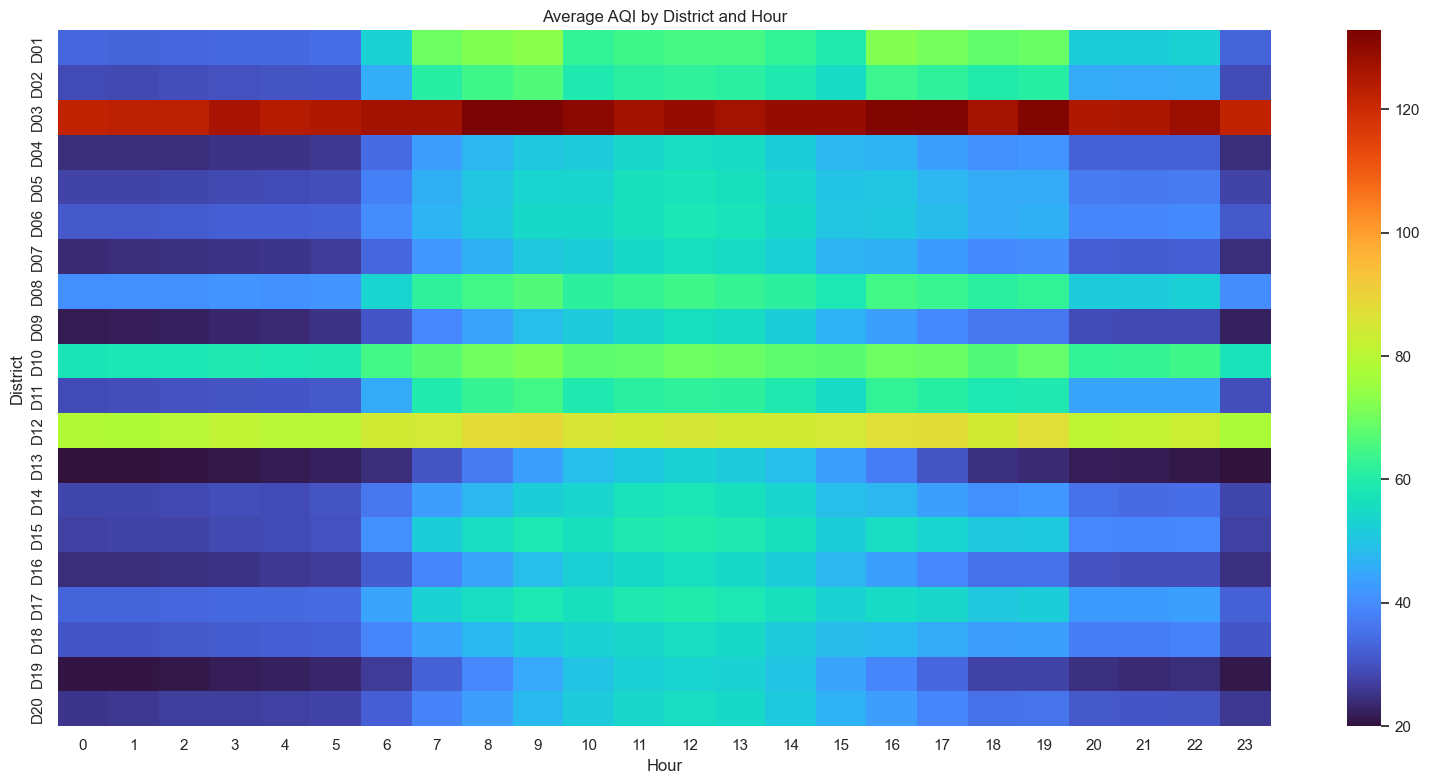

In [85]:
district_hour = df.pivot_table(
    index="district_id",
    columns="hour",
    values="synthetic_aqi",
    aggfunc="mean"
)
plt.figure(figsize=(16, 8))
sns.heatmap(district_hour, cmap="turbo")
plt.title("Average AQI by District and Hour")
plt.xlabel("Hour")
plt.ylabel("District")
plt.tight_layout()

- **Month vs district AQI heatmap**

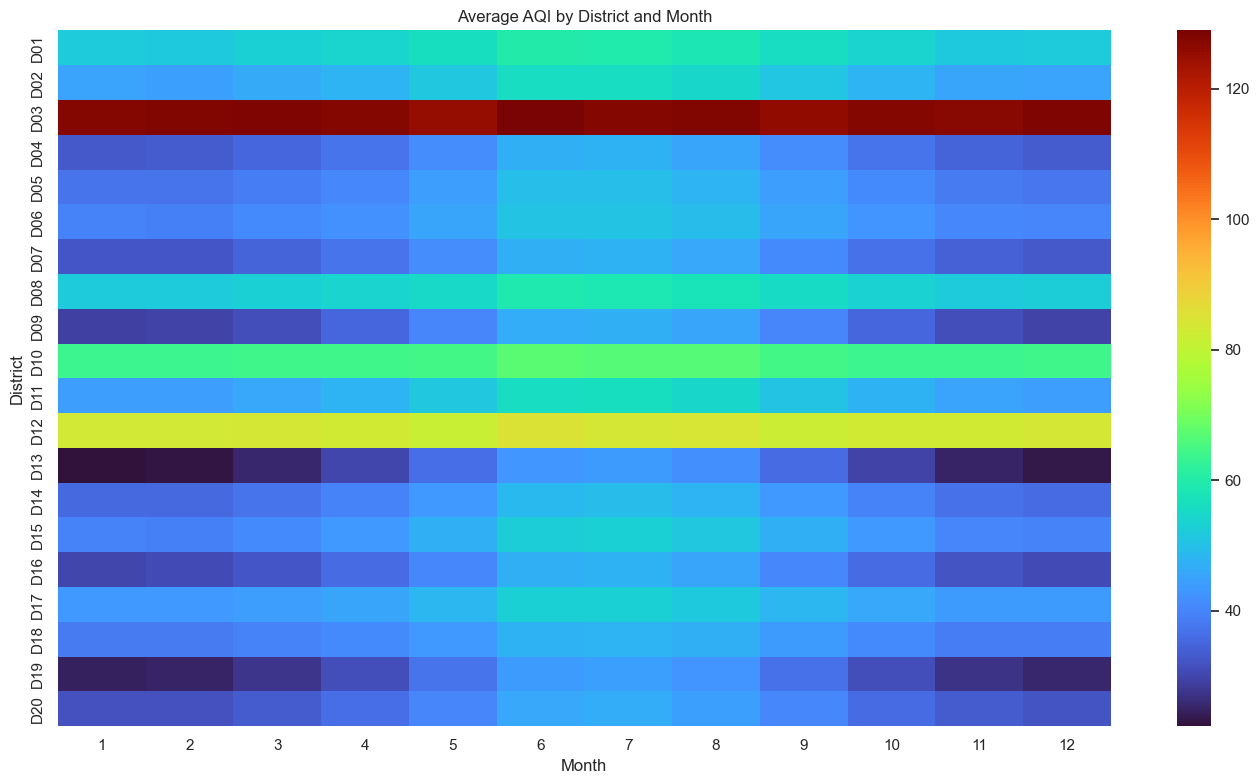

In [86]:
district_month = df.pivot_table(
    index="district_id",
    columns="month",
    values="synthetic_aqi",
    aggfunc="mean"
)
plt.figure(figsize=(14, 8))
sns.heatmap(district_month, cmap="turbo", annot=False)
plt.title("Average AQI by District and Month")
plt.xlabel("Month")
plt.ylabel("District")
plt.tight_layout()